# Pinar del Rio

In [1]:
print(1)

1


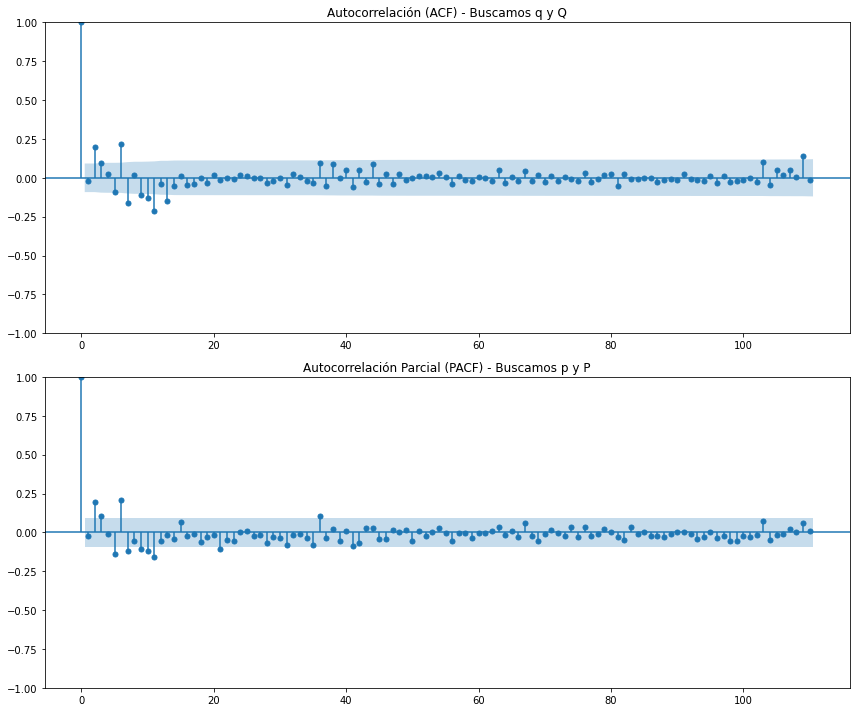

In [10]:
import pandas as pd
import os

import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

nombre_provincia = 'Pinar del Río'

carpeta_salida = 'dataframes_provincias'
nombre_archivo = f'{nombre_provincia.replace(" ", "_")}.csv'
ruta_completa = os.path.join(carpeta_salida, nombre_archivo)

df_pinar_del_rio = pd.read_csv(ruta_completa)

# lags=110 para ver claramente lo que pasa en el periodo 52 y 104
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
serie_diferenciada = df_pinar_del_rio["Casos_Dengue"].diff().dropna()
# ACF: Ayuda a identificar q (MA) y Q (SMA)
plot_acf(serie_diferenciada, lags=110, ax=ax1)
ax1.set_title('Autocorrelación (ACF) - Buscamos q y Q')

# PACF: Ayuda a identificar p (AR) y P (SAR)
plot_pacf(serie_diferenciada, lags=110, ax=ax2)
ax2.set_title('Autocorrelación Parcial (PACF) - Buscamos p y P')

plt.tight_layout()
plt.show()

In [11]:
df_pinar_del_rio= df_pinar_del_rio.drop(['Unnamed: 0', "Provincias"], axis=1)
df_pinar_del_rio.columns

Index(['Año_x', 'Semana Estadística', 'Fecha', 'Casos_Dengue', 'Temp_Med',
       'Hum_Rel', 'Precip', 'Año_y', 'Mes'],
      dtype='object')

In [14]:
import itertools
import statsmodels.api as sm

p =  [0,1,2]
q=[0,1,2]
d = [1]
P = D = Q = range(0, 2) # Estacionales 0 o 1
s = 52 

pdq = list(itertools.product(p, d, q))
seasonal_pdq = [(x[0], x[1], x[2], s) for x in list(itertools.product(P, D, Q))]
y = df_pinar_del_rio["Casos_Dengue"]

n_forecast = 4

train_y = y[:-n_forecast]
test_y = y[-n_forecast:]

mejores_params = None
mejor_aic = float("inf")

for param in pdq:
    for param_seasonal in seasonal_pdq:
        try:
            mod = sm.tsa.statespace.SARIMAX(train_y,
                                            order=param,
                                            seasonal_order=param_seasonal,
                                            enforce_stationarity=False,
                                            enforce_invertibility=False)
            results = mod.fit(disp=False)
            print(param,param_seasonal,results.aic)

            if results.aic < mejor_aic:
                mejor_aic = results.aic
                mejores_params = (param, param_seasonal)
                
        except:
            print(3)
            continue

print(f"Mejor SARIMA: {mejores_params} con AIC: {mejor_aic}")

(0, 1, 0) (0, 0, 0, 52) 4273.51900124916
(0, 1, 0) (0, 0, 1, 52) 3756.339617527008
(0, 1, 0) (0, 1, 0, 52) 4009.2064950537956
(0, 1, 0) (0, 1, 1, 52) 3380.2283758688004
(0, 1, 0) (1, 0, 0, 52) 3764.8932382028165
(0, 1, 0) (1, 0, 1, 52) 3758.339538708271
(0, 1, 0) (1, 1, 0, 52) 3443.295946966682
(0, 1, 0) (1, 1, 1, 52) 3373.1907715701154
(0, 1, 1) (0, 0, 0, 52) 4266.928162091259
(0, 1, 1) (0, 0, 1, 52) 3749.5829625478054
(0, 1, 1) (0, 1, 0, 52) 4001.81772776674
(0, 1, 1) (0, 1, 1, 52) 3373.310105122338
(0, 1, 1) (1, 0, 0, 52) 3766.5854737915497
(0, 1, 1) (1, 0, 1, 52) 3751.5828562531933
(0, 1, 1) (1, 1, 0, 52) 3443.490040411871
(0, 1, 1) (1, 1, 1, 52) 3365.7820410668737
(0, 1, 2) (0, 0, 0, 52) 4239.41193301294
(0, 1, 2) (0, 0, 1, 52) 3718.1712627558036
(0, 1, 2) (0, 1, 0, 52) 3970.4262225357825
(0, 1, 2) (0, 1, 1, 52) 3343.7712749986536
(0, 1, 2) (1, 0, 0, 52) 3743.4101575227214
(0, 1, 2) (1, 0, 1, 52) 3720.151228805823
(0, 1, 2) (1, 1, 0, 52) 3418.572998377448
(0, 1, 2) (1, 1, 1, 52) 3

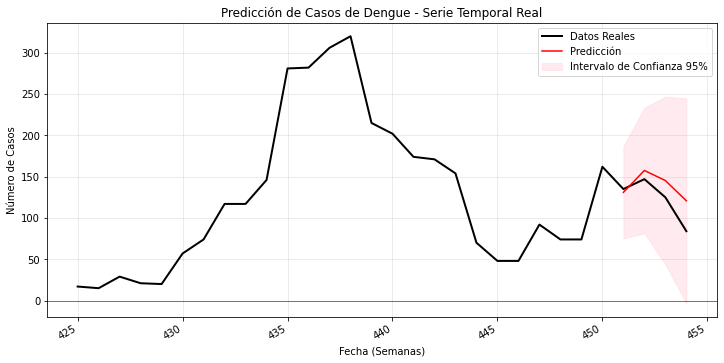

Error Absoluto Medio (MAE): 17.89 casos
Raíz del Error Cuadrático Medio (RMSE): 21.74 casos
Error Porcentual Absoluto Medio (MAPE): 17.53%


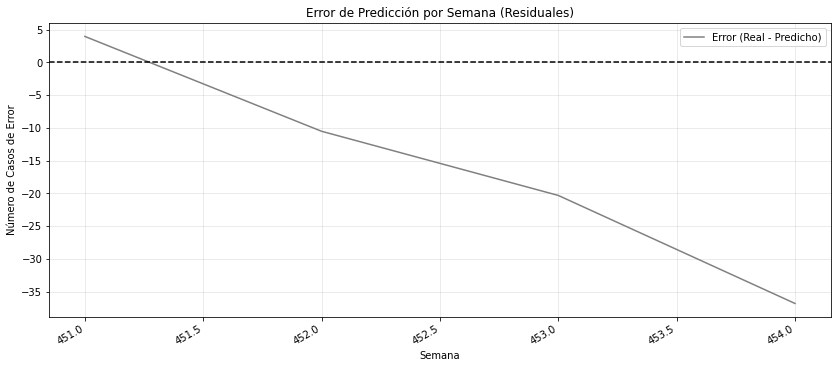

In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX

# df_pinar_del_rio['Fecha'] = pd.to_datetime(df_pinar_del_rio['Fecha'])
# df_pinar_del_rio = df_pinar_del_rio.set_index('Fecha')


model_final = SARIMAX(train_y, 
                       
                      order=(2, 1, 2), 
                      seasonal_order=(1, 1, 1, 52),
                      enforce_stationarity=False,
                      enforce_invertibility=False)
results_final = model_final.fit(disp=False)

forecast = results_final.get_forecast(steps=n_forecast )
forecast_df = forecast.summary_frame()
forecast_df.index = test_y.index

forecast_df['mean'] = np.clip(forecast_df['mean'], 0, None)
# forecast_df['mean_ci_lower'] = np.clip(forecast_df['mean_ci_lower'], 0, None)
# forecast_df['mean_ci_upper'] = np.clip(forecast_df['mean_ci_upper'], 0, None)

plt.figure(figsize=(12, 6))

plt.plot(y.index[-30:], y[-30:], label='Datos Reales', color='black', linewidth=2)

plt.plot(test_y.index, forecast_df['mean'], label='Predicción', color='red')

plt.fill_between(forecast_df.index, 
                 forecast_df['mean_ci_lower'], 
                 forecast_df['mean_ci_upper'], 
                 color='pink', alpha=0.3, label='Intervalo de Confianza 95%')

plt.gcf().autofmt_xdate() 

plt.title('Predicción de Casos de Dengue - Serie Temporal Real')
plt.xlabel('Fecha (Semanas)')
plt.ylabel('Número de Casos')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axhline(0, color='black', linewidth=1, alpha=0.5) # Línea en el cero
plt.show()
y_true = test_y
y_pred = forecast_df['mean']

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_true, y_pred)

print(f"Error Absoluto Medio (MAE): {mae:.2f} casos")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse:.2f} casos")
print(f"Error Porcentual Absoluto Medio (MAPE): {mape*100:.2f}%")

error_semanal = y_true - y_pred

plt.figure(figsize=(14, 6))
plt.plot(error_semanal.index, error_semanal, color='gray', label='Error (Real - Predicho)')
plt.axhline(0, color='black', linestyle='--', linewidth=1.5)
plt.title('Error de Predicción por Semana (Residuales)')
plt.xlabel('Semana')
plt.ylabel('Número de Casos de Error')
plt.legend()
plt.grid(True, alpha=0.3)
plt.gcf().autofmt_xdate()
plt.show()

In [4]:
df_pinar_del_rio

,Año_x,Semana Estadística,Fecha,Casos_Dengue,Temperatura med,Humedad Relat,Precipitaciones,Año_y,Mes,Temperatura med_lag17
0,2014,18,2014-05-05,0.0,26.150,77.500,36.1625,2014.0,5.0,21.7000
1,2014,19,2014-05-12,0.0,26.275,78.750,36.1625,2014.0,5.0,22.2125
2,2014,20,2014-05-19,33.0,26.400,80.000,36.1625,2014.0,5.0,22.7250
3,2014,21,2014-05-26,0.0,26.525,81.250,36.1625,2014.0,5.0,23.2375
4,2014,22,2014-06-02,0.0,26.650,82.500,37.3900,2014.0,6.0,23.7500
...,...,...,...,...,...,...,...,...,...,...
436,2022,45,2022-11-07,162.0,26.150,80.000,23.5375,2022.0,11.0,27.7375
437,2022,46,2022-11-14,135.0,25.600,79.625,23.5375,2022.0,11.0,27.7750
438,2022,47,2022-11-21,147.0,25.050,79.250,23.5375,2022.0,11.0,27.8125
439,2022,48,2022-11-28,125.0,24.500,78.875,23.5375,2022.0,11.0,27.8500


# Artemisa

Index(['Año_x', 'Semana Estadística', 'Fecha', 'Casos_Dengue', 'Temp_Med',
       'Hum_Rel', 'Precip', 'Año_y', 'Mes'],
      dtype='object')


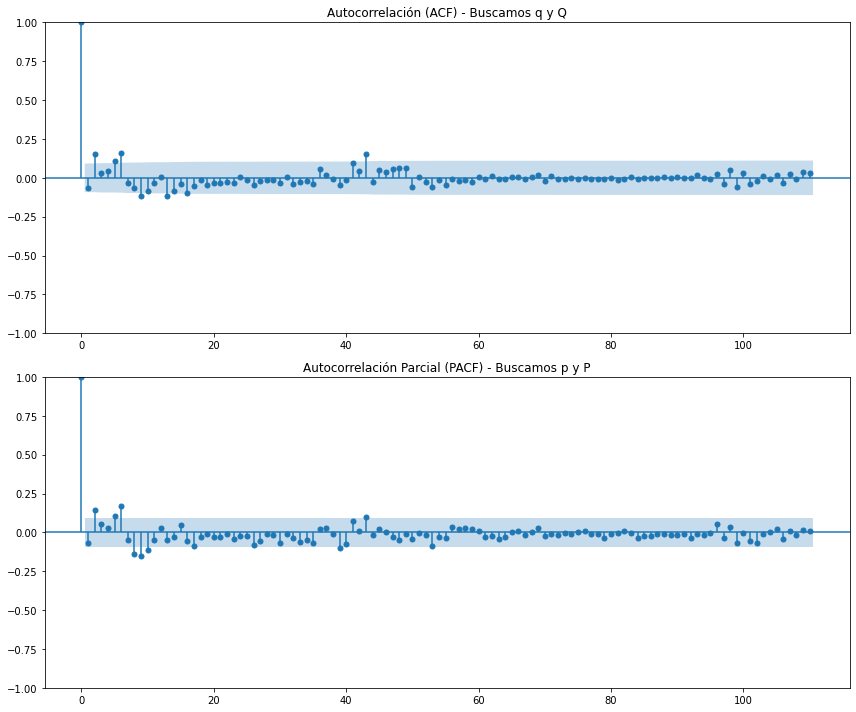

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import pandas as pd
import os

nombre_provincia = 'Artemisa'

carpeta_salida = 'dataframes_provincias'
nombre_archivo = f'{nombre_provincia.replace(" ", "_")}.csv'
ruta_completa = os.path.join(carpeta_salida, nombre_archivo)

df_artemisa = pd.read_csv(ruta_completa)

df_artemisa= df_artemisa.drop(['Unnamed: 0', "Provincias"], axis=1)
print(df_artemisa.columns)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

serie_diferenciada = df_artemisa["Casos_Dengue"].diff().dropna()

# ACF: Ayuda a identificar q (MA) y Q (SMA)
plot_acf(serie_diferenciada, lags=110, ax=ax1)
ax1.set_title('Autocorrelación (ACF) - Buscamos q y Q')

# PACF: Ayuda a identificar p (AR) y P (SAR)
plot_pacf(serie_diferenciada, lags=110, ax=ax2)
ax2.set_title('Autocorrelación Parcial (PACF) - Buscamos p y P')

plt.tight_layout()
plt.show()

In [18]:
import itertools
import statsmodels.api as sm

p =  [0,1,2]
q=[0,1,2]
d = [1]
P = D = Q = range(0, 2) # Estacionales 0 o 1
s = 52 

pdq = list(itertools.product(p, d, q))
seasonal_pdq = [(x[0], x[1], x[2], s) for x in list(itertools.product(P, D, Q))]
y = df_artemisa["Casos_Dengue"]

n_forecast = 4

train_y = y[:-n_forecast]
 
test_y = y[-n_forecast:]
    
mejores_params = None
mejor_aic = float("inf")

for param in pdq:
    for param_seasonal in seasonal_pdq:
        try:
            mod = sm.tsa.statespace.SARIMAX(train_y,
                                            order=param,
                                            seasonal_order=param_seasonal,
                                            enforce_stationarity=False,
                                            enforce_invertibility=False)
            results = mod.fit(disp=False)
            print(param,param_seasonal,results.aic)

            if results.aic < mejor_aic:
                mejor_aic = results.aic
                mejores_params = (param, param_seasonal)
                
        except:
            continue

print(f"Mejor SARIMA: {mejores_params} con AIC: {mejor_aic}")

(0, 1, 0) (0, 0, 0, 52) 3405.5494692099765
(0, 1, 0) (0, 0, 1, 52) 3059.1795398384866
(0, 1, 0) (0, 1, 0, 52) 3257.900302812316
(0, 1, 0) (0, 1, 1, 52) 2679.3682702494816
(0, 1, 0) (1, 0, 0, 52) 3066.4084190926596
(0, 1, 0) (1, 0, 1, 52) 3056.4156590849416
(0, 1, 0) (1, 1, 0, 52) 2735.0198944298686
(0, 1, 0) (1, 1, 1, 52) 2707.6901413541113
(0, 1, 1) (0, 0, 0, 52) 3397.93057744787
(0, 1, 1) (0, 0, 1, 52) 3051.0892349833157
(0, 1, 1) (0, 1, 0, 52) 3249.3014294532195
(0, 1, 1) (0, 1, 1, 52) 2673.6281085337773
(0, 1, 1) (1, 0, 0, 52) 3065.036634514905
(0, 1, 1) (1, 0, 1, 52) 3048.911875676015
(0, 1, 1) (1, 1, 0, 52) 2736.4991382221324
(0, 1, 1) (1, 1, 1, 52) 2699.3023711916608
(0, 1, 2) (0, 0, 0, 52) 3385.5050216442414
(0, 1, 2) (0, 0, 1, 52) 3040.49066532686
(0, 1, 2) (0, 1, 0, 52) 3229.8179733228444
(0, 1, 2) (0, 1, 1, 52) 2657.238251118237
(0, 1, 2) (1, 0, 0, 52) 3060.974834080282
(0, 1, 2) (1, 0, 1, 52) 3037.0544008749494
(0, 1, 2) (1, 1, 0, 52) 2719.4385893158296
(0, 1, 2) (1, 1, 1, 

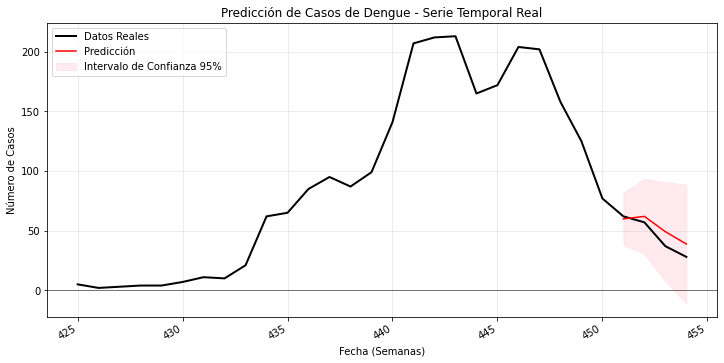

Error Absoluto Medio (MAE): 7.52 casos
Raíz del Error Cuadrático Medio (RMSE): 8.57 casos
Error Porcentual Absoluto Medio (MAPE): 20.91%


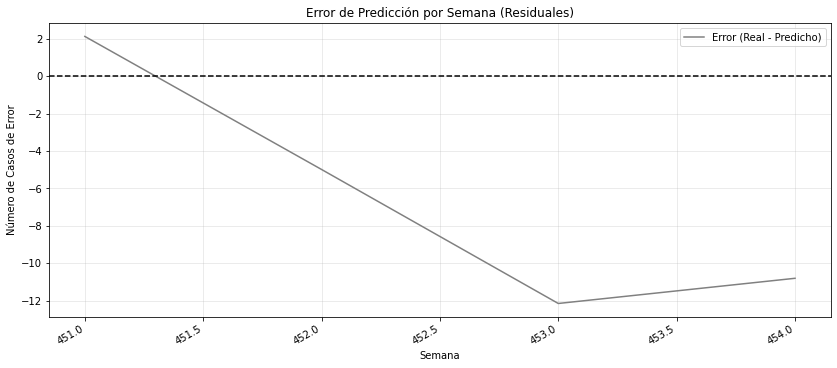

In [19]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX

# df_pinar_del_rio['Fecha'] = pd.to_datetime(df_pinar_del_rio['Fecha'])
# df_pinar_del_rio = df_pinar_del_rio.set_index('Fecha')


model_final = SARIMAX(train_y, 
                       
                      order=(0, 1, 2), 
                      seasonal_order=(0, 1, 1, 52),
                      enforce_stationarity=False,
                      enforce_invertibility=False)
results_final = model_final.fit(disp=False)

forecast = results_final.get_forecast(steps=n_forecast )
forecast_df = forecast.summary_frame()
forecast_df.index = test_y.index

forecast_df['mean'] = np.clip(forecast_df['mean'], 0, None)
# forecast_df['mean_ci_lower'] = np.clip(forecast_df['mean_ci_lower'], 0, None)
# forecast_df['mean_ci_upper'] = np.clip(forecast_df['mean_ci_upper'], 0, None)

plt.figure(figsize=(12, 6))

plt.plot(y.index[-30:], y[-30:], label='Datos Reales', color='black', linewidth=2)

plt.plot(test_y.index, forecast_df['mean'], label='Predicción', color='red')

plt.fill_between(forecast_df.index, 
                 forecast_df['mean_ci_lower'], 
                 forecast_df['mean_ci_upper'], 
                 color='pink', alpha=0.3, label='Intervalo de Confianza 95%')

plt.gcf().autofmt_xdate() 

plt.title('Predicción de Casos de Dengue - Serie Temporal Real')
plt.xlabel('Fecha (Semanas)')
plt.ylabel('Número de Casos')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axhline(0, color='black', linewidth=1, alpha=0.5) # Línea en el cero
plt.show()
y_true = test_y
y_pred = forecast_df['mean']

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_true, y_pred)

print(f"Error Absoluto Medio (MAE): {mae:.2f} casos")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse:.2f} casos")
print(f"Error Porcentual Absoluto Medio (MAPE): {mape*100:.2f}%")

error_semanal = y_true - y_pred

plt.figure(figsize=(14, 6))
plt.plot(error_semanal.index, error_semanal, color='gray', label='Error (Real - Predicho)')
plt.axhline(0, color='black', linestyle='--', linewidth=1.5)
plt.title('Error de Predicción por Semana (Residuales)')
plt.xlabel('Semana')
plt.ylabel('Número de Casos de Error')
plt.legend()
plt.grid(True, alpha=0.3)
plt.gcf().autofmt_xdate()
plt.show()

# La Habana

Index(['Año_x', 'Semana Estadística', 'Fecha', 'Casos_Dengue', 'Temp_Med',
       'Hum_Rel', 'Precip', 'Año_y', 'Mes'],
      dtype='object')


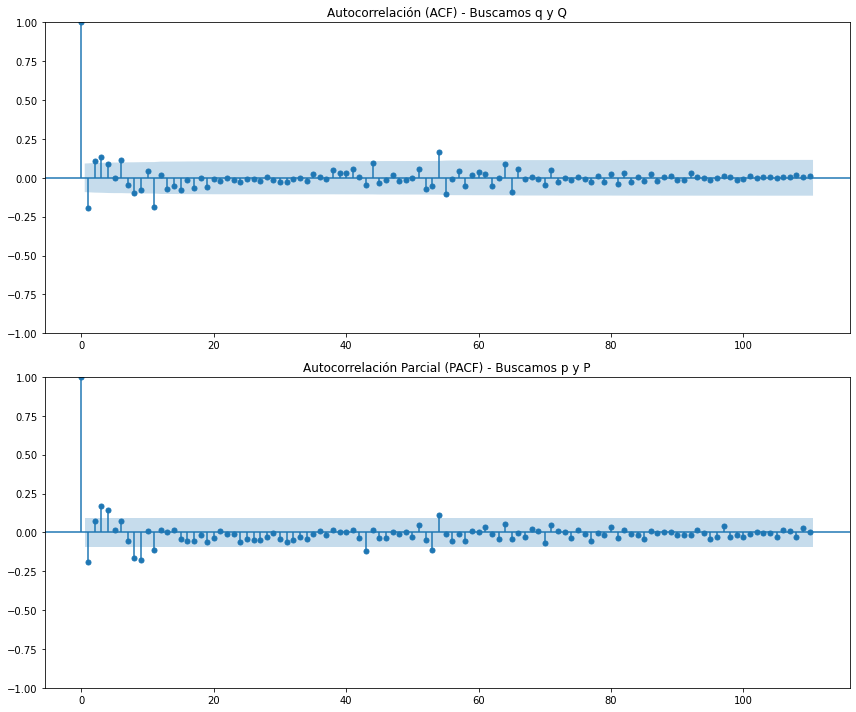

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import pandas as pd
import os

nombre_provincia = 'La_Habana'

carpeta_salida = 'dataframes_provincias'
nombre_archivo = f'{nombre_provincia.replace(" ", "_")}.csv'
ruta_completa = os.path.join(carpeta_salida, nombre_archivo)

df= pd.read_csv(ruta_completa)

df= df.drop(['Unnamed: 0', "Provincias"], axis=1)
print(df.columns)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

serie_diferenciada = df["Casos_Dengue"].diff().dropna()

# ACF: Ayuda a identificar q (MA) y Q (SMA)
plot_acf(serie_diferenciada, lags=110, ax=ax1)
ax1.set_title('Autocorrelación (ACF) - Buscamos q y Q')

# PACF: Ayuda a identificar p (AR) y P (SAR)
plot_pacf(serie_diferenciada, lags=110, ax=ax2)
ax2.set_title('Autocorrelación Parcial (PACF) - Buscamos p y P')

plt.tight_layout()
plt.show()

In [21]:
import itertools
import statsmodels.api as sm

p =  [0,1,2,3,4]
q=[0,1,2,3]
d = [1]
P = D = Q = range(0, 2) # Estacionales 0 o 1
s = 52 

pdq = list(itertools.product(p, d, q))
seasonal_pdq = [(x[0], x[1], x[2], s) for x in list(itertools.product(P, D, Q))]
y = df["Casos_Dengue"]

n_forecast = 4

train_y = y[:-n_forecast]
 
test_y = y[-n_forecast:]
 

mejores_params = None
mejor_aic = float("inf")

for param in pdq:
    for param_seasonal in seasonal_pdq:
        try:
            mod = sm.tsa.statespace.SARIMAX(train_y,
                                            order=param,
                                            seasonal_order=param_seasonal,
                                            enforce_stationarity=False,
                                            enforce_invertibility=False)
            results = mod.fit(disp=False)
            print(param,param_seasonal,results.aic)

            if results.aic < mejor_aic:
                mejor_aic = results.aic
                mejores_params = (param, param_seasonal)
                
        except:
            continue

print(f"Mejor SARIMA: {mejores_params} con AIC: {mejor_aic}")

(0, 1, 0) (0, 0, 0, 52) 6122.438135961498
(0, 1, 0) (0, 0, 1, 52) 5372.534267016568
(0, 1, 0) (0, 1, 0, 52) 5647.730358488737
(0, 1, 0) (0, 1, 1, 52) 4629.93664291706
(0, 1, 0) (1, 0, 0, 52) 5381.366017281876
(0, 1, 0) (1, 0, 1, 52) 5346.737510864317
(0, 1, 0) (1, 1, 0, 52) 4663.928586755852
(0, 1, 0) (1, 1, 1, 52) 4650.788862232577
(0, 1, 1) (0, 0, 0, 52) 6097.268830801728
(0, 1, 1) (0, 0, 1, 52) 5355.136901208262
(0, 1, 1) (0, 1, 0, 52) 5612.55404659022
(0, 1, 1) (0, 1, 1, 52) 4619.99636485843
(0, 1, 1) (1, 0, 0, 52) 5376.300067566968
(0, 1, 1) (1, 0, 1, 52) 5332.37763931309
(0, 1, 1) (1, 1, 0, 52) 4665.834177041104
(0, 1, 1) (1, 1, 1, 52) 4640.308564318448
(0, 1, 2) (0, 0, 0, 52) 6075.00440889968
(0, 1, 2) (0, 0, 1, 52) 5331.864931720653
(0, 1, 2) (0, 1, 0, 52) 5598.402531390486
(0, 1, 2) (0, 1, 1, 52) 4583.1166905928085
(0, 1, 2) (1, 0, 0, 52) 5361.4654255881305
(0, 1, 2) (1, 0, 1, 52) 5297.505513596687
(0, 1, 2) (1, 1, 0, 52) 4645.336471115762
(0, 1, 2) (1, 1, 1, 52) 4584.25334219

/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(2, 1, 1) (1, 1, 0, 52) 4611.294600139743
(2, 1, 1) (1, 1, 1, 52) 4592.680537976565
(2, 1, 2) (0, 0, 0, 52) 6047.8574243600815
(2, 1, 2) (0, 0, 1, 52) 5311.992159259907
(2, 1, 2) (0, 1, 0, 52) 5565.714277247221


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(2, 1, 2) (0, 1, 1, 52) 4586.869499171493
(2, 1, 2) (1, 0, 0, 52) 5321.29364934792
(2, 1, 2) (1, 0, 1, 52) 5288.656113660794
(2, 1, 2) (1, 1, 0, 52) 4606.84458803927


...

(4, 1, 3) (1, 0, 1, 52) 5278.969892866633


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(4, 1, 3) (1, 1, 0, 52) 4652.502404145319


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(4, 1, 3) (1, 1, 1, 52) 4646.010870057607
Mejor SARIMA: ((2, 1, 3), (0, 1, 1, 52)) con AIC: 4549.116630878424


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


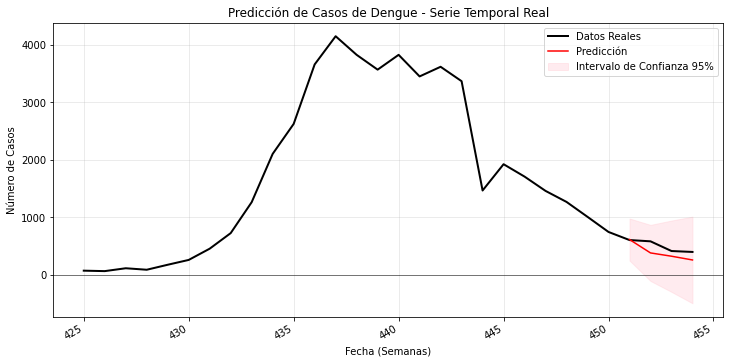

Error Absoluto Medio (MAE): 110.34 casos
Raíz del Error Cuadrático Medio (RMSE): 130.94 casos
Error Porcentual Absoluto Medio (MAPE): 23.43%


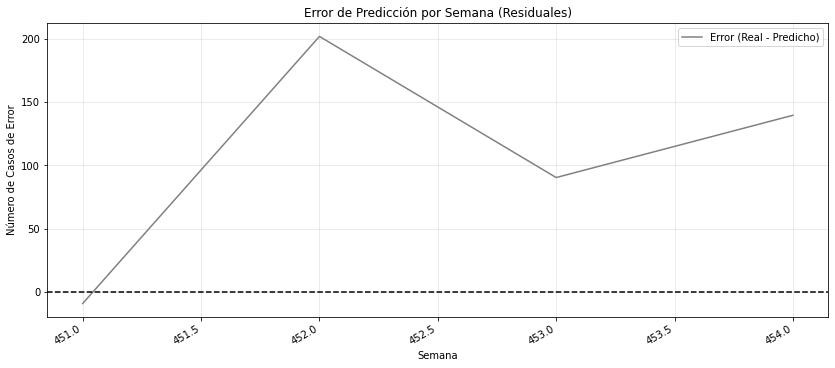

In [22]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX

model_final = SARIMAX(train_y, 
                       
                      order=(2, 1, 3), 
                      seasonal_order=(0, 1, 1, 52),
                      enforce_stationarity=False,
                      enforce_invertibility=False)
results_final = model_final.fit(disp=False)

forecast = results_final.get_forecast(steps=n_forecast )
forecast_df = forecast.summary_frame()
forecast_df.index = test_y.index

forecast_df['mean'] = np.clip(forecast_df['mean'], 0, None)
# forecast_df['mean_ci_lower'] = np.clip(forecast_df['mean_ci_lower'], 0, None)
# forecast_df['mean_ci_upper'] = np.clip(forecast_df['mean_ci_upper'], 0, None)

plt.figure(figsize=(12, 6))

plt.plot(y.index[-30:], y[-30:], label='Datos Reales', color='black', linewidth=2)

plt.plot(test_y.index, forecast_df['mean'], label='Predicción', color='red')

plt.fill_between(forecast_df.index, 
                 forecast_df['mean_ci_lower'], 
                 forecast_df['mean_ci_upper'], 
                 color='pink', alpha=0.3, label='Intervalo de Confianza 95%')

plt.gcf().autofmt_xdate() 

plt.title('Predicción de Casos de Dengue - Serie Temporal Real')
plt.xlabel('Fecha (Semanas)')
plt.ylabel('Número de Casos')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axhline(0, color='black', linewidth=1, alpha=0.5) # Línea en el cero
plt.show()
y_true = test_y
y_pred = forecast_df['mean']

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_true, y_pred)

print(f"Error Absoluto Medio (MAE): {mae:.2f} casos")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse:.2f} casos")
print(f"Error Porcentual Absoluto Medio (MAPE): {mape*100:.2f}%")

error_semanal = y_true - y_pred

plt.figure(figsize=(14, 6))
plt.plot(error_semanal.index, error_semanal, color='gray', label='Error (Real - Predicho)')
plt.axhline(0, color='black', linestyle='--', linewidth=1.5)
plt.title('Error de Predicción por Semana (Residuales)')
plt.xlabel('Semana')
plt.ylabel('Número de Casos de Error')
plt.legend()
plt.grid(True, alpha=0.3)
plt.gcf().autofmt_xdate()
plt.show()

# Mayabeque

Index(['Año_x', 'Semana Estadística', 'Fecha', 'Casos_Dengue', 'Temp_Med',
       'Hum_Rel', 'Precip', 'Año_y', 'Mes'],
      dtype='object')


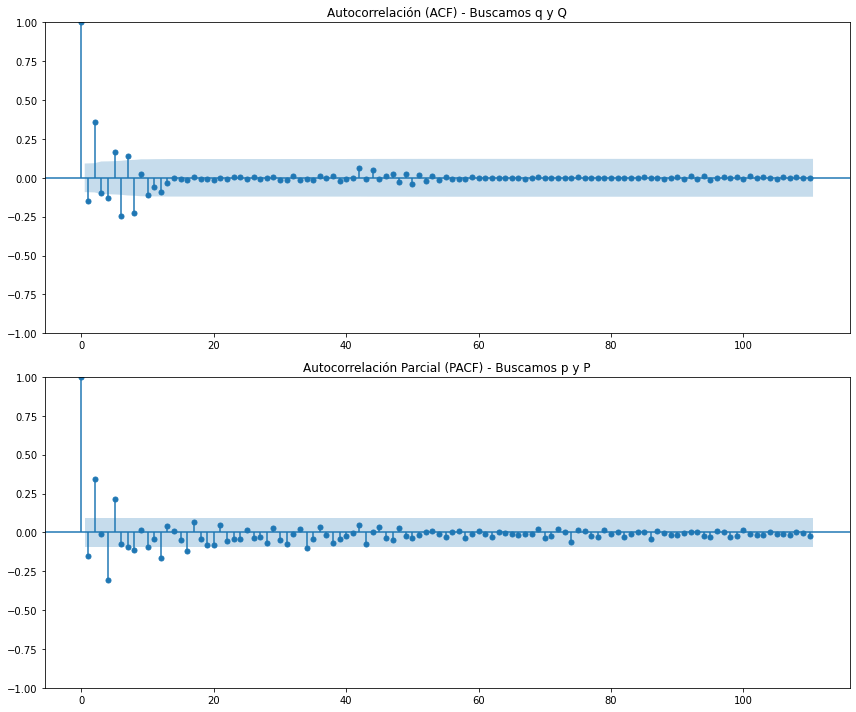

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import pandas as pd
import os

nombre_provincia = 'Mayabeque'

carpeta_salida = 'dataframes_provincias'
nombre_archivo = f'{nombre_provincia.replace(" ", "_")}.csv'
ruta_completa = os.path.join(carpeta_salida, nombre_archivo)

df= pd.read_csv(ruta_completa)

df= df.drop(['Unnamed: 0', "Provincias"], axis=1)
print(df.columns)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

serie_diferenciada = df["Casos_Dengue"].diff().dropna()

# ACF: Ayuda a identificar q (MA) y Q (SMA)
plot_acf(serie_diferenciada, lags=110, ax=ax1)
ax1.set_title('Autocorrelación (ACF) - Buscamos q y Q')

# PACF: Ayuda a identificar p (AR) y P (SAR)
plot_pacf(serie_diferenciada, lags=110, ax=ax2)
ax2.set_title('Autocorrelación Parcial (PACF) - Buscamos p y P')

plt.tight_layout()
plt.show()

In [24]:
import itertools
import statsmodels.api as sm

p =  [0,1,2]
q=[0,1,2,3]
d = [1]
P = D = Q = range(0, 2) # Estacionales 0 o 1
s = 52 

pdq = list(itertools.product(p, d, q))
seasonal_pdq = [(x[0], x[1], x[2], s) for x in list(itertools.product(P, D, Q))]
y = df["Casos_Dengue"]

n_forecast = 4

train_y = y[:-n_forecast]
 
test_y = y[-n_forecast:]
 

mejores_params = None
mejor_aic = float("inf")

for param in pdq:
    for param_seasonal in seasonal_pdq:
        try:
            mod = sm.tsa.statespace.SARIMAX(train_y,
                                            
                                            order=param,
                                            seasonal_order=param_seasonal,
                                            enforce_stationarity=False,
                                            enforce_invertibility=False)
            results = mod.fit(disp=False)
            print(param,param_seasonal,results.aic)

            if results.aic < mejor_aic:
                mejor_aic = results.aic
                mejores_params = (param, param_seasonal)
                
        except:
            continue

print(f"Mejor SARIMA: {mejores_params} con AIC: {mejor_aic}")

(0, 1, 0) (0, 0, 0, 52) 3940.8234777653106
(0, 1, 0) (0, 0, 1, 52) 3535.1935775383713
(0, 1, 0) (0, 1, 0, 52) 3585.9894984703424
(0, 1, 0) (0, 1, 1, 52) 3134.950780798437
(0, 1, 0) (1, 0, 0, 52) 3542.7571335309226
(0, 1, 0) (1, 0, 1, 52) 3536.8645268226883
(0, 1, 0) (1, 1, 0, 52) 3148.1389363313733
(0, 1, 0) (1, 1, 1, 52) 3139.056659869515
(0, 1, 1) (0, 0, 0, 52) 3928.514784402892
(0, 1, 1) (0, 0, 1, 52) 3523.563126268884
(0, 1, 1) (0, 1, 0, 52) 3575.360191609411
(0, 1, 1) (0, 1, 1, 52) 3123.248982244617
(0, 1, 1) (1, 0, 0, 52) 3539.0609941400326
(0, 1, 1) (1, 0, 1, 52) 3525.2936722918553
(0, 1, 1) (1, 1, 0, 52) 3145.344138607041
(0, 1, 1) (1, 1, 1, 52) 3127.534868746412
(0, 1, 2) (0, 0, 0, 52) 3827.659167417838
(0, 1, 2) (0, 0, 1, 52) 3433.9943915549898
(0, 1, 2) (0, 1, 0, 52) 3505.987317133043
(0, 1, 2) (0, 1, 1, 52) 3050.7965505523816
(0, 1, 2) (1, 0, 0, 52) 3457.002818382288
(0, 1, 2) (1, 0, 1, 52) 3435.9922538842256
(0, 1, 2) (1, 1, 0, 52) 3086.920978096671
(0, 1, 2) (1, 1, 1, 52)

/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(2, 1, 3) (1, 1, 1, 52) 3009.2028986062096
Mejor SARIMA: ((2, 1, 3), (0, 1, 1, 52)) con AIC: 2999.738080405308


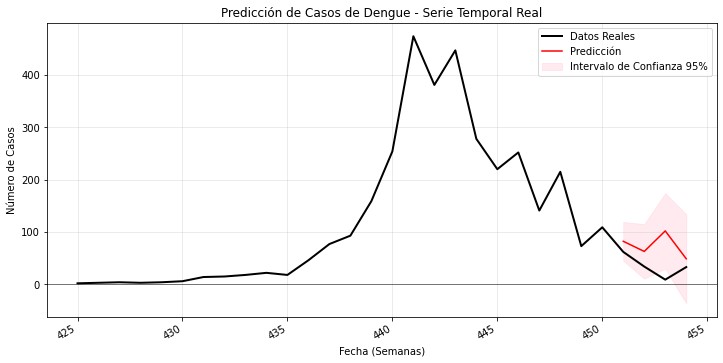

Error Absoluto Medio (MAE): 39.53 casos
Raíz del Error Cuadrático Medio (RMSE): 50.40 casos
Error Porcentual Absoluto Medio (MAPE): 300.01%


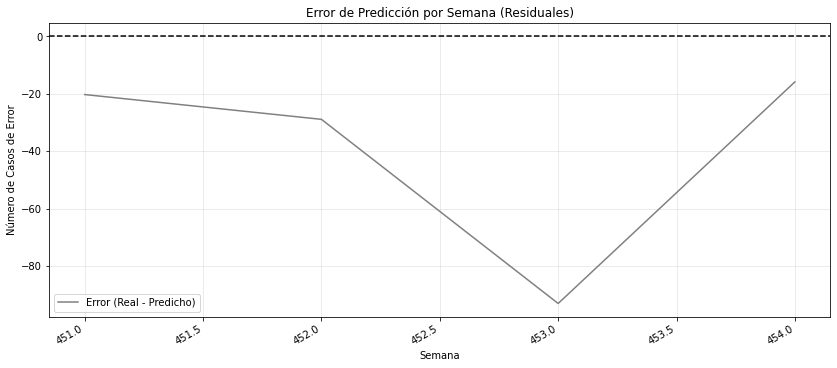

In [25]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX

model_final = SARIMAX(train_y, 
                       
                      order=(2, 1, 3), 
                      seasonal_order=(0, 1, 1, 52),
                      enforce_stationarity=False,
                      enforce_invertibility=False)
results_final = model_final.fit(disp=False)

forecast = results_final.get_forecast(steps=n_forecast )
forecast_df = forecast.summary_frame()
forecast_df.index = test_y.index

forecast_df['mean'] = np.clip(forecast_df['mean'], 0, None)
# forecast_df['mean_ci_lower'] = np.clip(forecast_df['mean_ci_lower'], 0, None)
# forecast_df['mean_ci_upper'] = np.clip(forecast_df['mean_ci_upper'], 0, None)

plt.figure(figsize=(12, 6))

plt.plot(y.index[-30:], y[-30:], label='Datos Reales', color='black', linewidth=2)

plt.plot(test_y.index, forecast_df['mean'], label='Predicción', color='red')

plt.fill_between(forecast_df.index, 
                 forecast_df['mean_ci_lower'], 
                 forecast_df['mean_ci_upper'], 
                 color='pink', alpha=0.3, label='Intervalo de Confianza 95%')

plt.gcf().autofmt_xdate() 

plt.title('Predicción de Casos de Dengue - Serie Temporal Real')
plt.xlabel('Fecha (Semanas)')
plt.ylabel('Número de Casos')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axhline(0, color='black', linewidth=1, alpha=0.5) # Línea en el cero
plt.show()
y_true = test_y
y_pred = forecast_df['mean']

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_true, y_pred)

print(f"Error Absoluto Medio (MAE): {mae:.2f} casos")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse:.2f} casos")
print(f"Error Porcentual Absoluto Medio (MAPE): {mape*100:.2f}%")

error_semanal = y_true - y_pred

plt.figure(figsize=(14, 6))
plt.plot(error_semanal.index, error_semanal, color='gray', label='Error (Real - Predicho)')
plt.axhline(0, color='black', linestyle='--', linewidth=1.5)
plt.title('Error de Predicción por Semana (Residuales)')
plt.xlabel('Semana')
plt.ylabel('Número de Casos de Error')
plt.legend()
plt.grid(True, alpha=0.3)
plt.gcf().autofmt_xdate()
plt.show()

# Matanzas

Index(['Año_x', 'Semana Estadística', 'Fecha', 'Casos_Dengue', 'Temp_Med',
       'Hum_Rel', 'Precip', 'Año_y', 'Mes'],
      dtype='object')


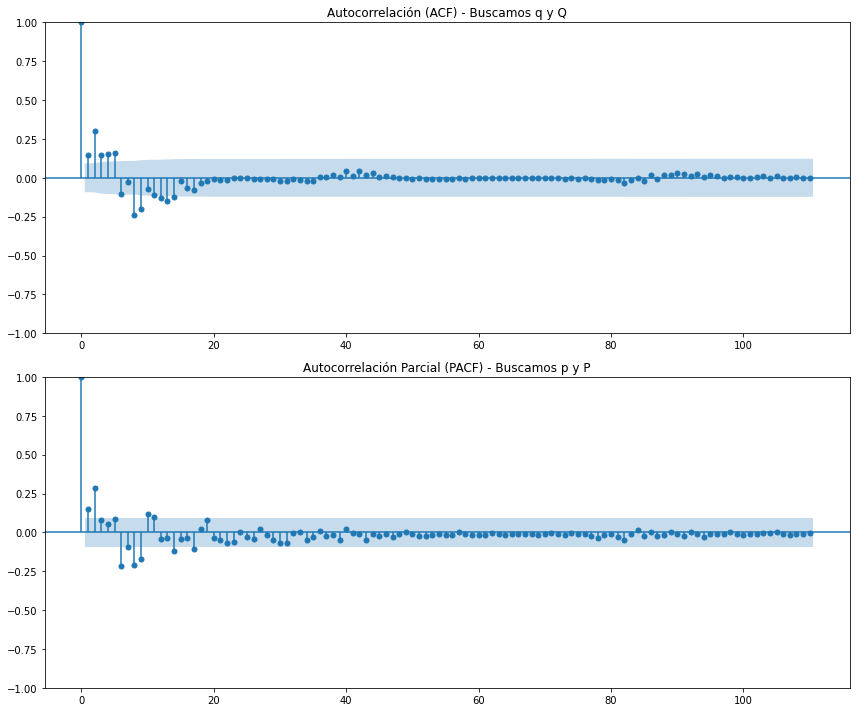

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import pandas as pd
import os

nombre_provincia = 'Matanzas'

carpeta_salida = 'dataframes_provincias'
nombre_archivo = f'{nombre_provincia.replace(" ", "_")}.csv'
ruta_completa = os.path.join(carpeta_salida, nombre_archivo)

df= pd.read_csv(ruta_completa)

df= df.drop(['Unnamed: 0', "Provincias"], axis=1)
print(df.columns)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

serie_diferenciada = df["Casos_Dengue"].diff().dropna()

# ACF: Ayuda a identificar q (MA) y Q (SMA)
plot_acf(serie_diferenciada, lags=110, ax=ax1)
ax1.set_title('Autocorrelación (ACF) - Buscamos q y Q')

# PACF: Ayuda a identificar p (AR) y P (SAR)
plot_pacf(serie_diferenciada, lags=110, ax=ax2)
ax2.set_title('Autocorrelación Parcial (PACF) - Buscamos p y P')

plt.tight_layout()
plt.show()

In [27]:
import itertools
import statsmodels.api as sm

q =  [0,1,2,3,4,5]
p=[0,1,2]
d = [1]
P = D = Q = range(0, 2) # Estacionales 0 o 1
s = 52 

pdq = list(itertools.product(p, d, q))
seasonal_pdq = [(x[0], x[1], x[2], s) for x in list(itertools.product(P, D, Q))]
y = df["Casos_Dengue"]

n_forecast = 4

train_y = y[:-n_forecast]
 
test_y = y[-n_forecast:]
 

mejores_params = None
mejor_aic = float("inf")

for param in pdq:
    for param_seasonal in seasonal_pdq:
        try:
            mod = sm.tsa.statespace.SARIMAX(train_y,
                                            
                                            order=param,
                                            seasonal_order=param_seasonal,
                                            enforce_stationarity=False,
                                            enforce_invertibility=False)
            results = mod.fit(disp=False)
            print(param,param_seasonal,results.aic)

            if results.aic < mejor_aic:
                mejor_aic = results.aic
                mejores_params = (param, param_seasonal)
                
        except:
            continue

print(f"Mejor SARIMA: {mejores_params} con AIC: {mejor_aic}")

(0, 1, 0) (0, 0, 0, 52) 4177.712159636781
(0, 1, 0) (0, 0, 1, 52) 3744.775725217339
(0, 1, 0) (0, 1, 0, 52) 3779.1646753063196
(0, 1, 0) (0, 1, 1, 52) 3300.1715003193895
(0, 1, 0) (1, 0, 0, 52) 3753.0051507859553
(0, 1, 0) (1, 0, 1, 52) 3746.582697986814
(0, 1, 0) (1, 1, 0, 52) 3307.880288356727
(0, 1, 0) (1, 1, 1, 52) 3301.1389631976726
(0, 1, 1) (0, 0, 0, 52) 4165.922968819162
(0, 1, 1) (0, 0, 1, 52) 3733.5191616652537
(0, 1, 1) (0, 1, 0, 52) 3769.1042596700095
(0, 1, 1) (0, 1, 1, 52) 3288.3608688002237
(0, 1, 1) (1, 0, 0, 52) 3750.201540843516
(0, 1, 1) (1, 0, 1, 52) 3735.3732279723263
(0, 1, 1) (1, 1, 0, 52) 3305.2073103759126
(0, 1, 1) (1, 1, 1, 52) 3289.893450496197
(0, 1, 2) (0, 0, 0, 52) 4127.743149505233
(0, 1, 2) (0, 0, 1, 52) 3699.0248048341336
(0, 1, 2) (0, 1, 0, 52) 3734.028340888211
(0, 1, 2) (0, 1, 1, 52) 3256.150580384567
(0, 1, 2) (1, 0, 0, 52) 3724.0330524445485
(0, 1, 2) (1, 0, 1, 52) 3700.960477223888
(0, 1, 2) (1, 1, 0, 52) 3281.5867165850223
(0, 1, 2) (1, 1, 1, 52

/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(2, 1, 4) (1, 0, 1, 52) 3628.0875165767147
(2, 1, 4) (1, 1, 0, 52) 3210.203981541095
(2, 1, 4) (1, 1, 1, 52) 3185.748122705687
(2, 1, 5) (0, 0, 0, 52) 4031.591102033858
(2, 1, 5) (0, 0, 1, 52) 3611.103076424842


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(2, 1, 5) (0, 1, 0, 52) 3642.3942377259427
(2, 1, 5) (0, 1, 1, 52) 3181.0212504497595
(2, 1, 5) (1, 0, 0, 52) 3644.7137039078943
(2, 1, 5) (1, 0, 1, 52) 3613.0904692930844


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(2, 1, 5) (1, 1, 0, 52) 3193.09935494587


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(2, 1, 5) (1, 1, 1, 52) 3160.8837272128967
Mejor SARIMA: ((2, 1, 5), (1, 1, 1, 52)) con AIC: 3160.8837272128967


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


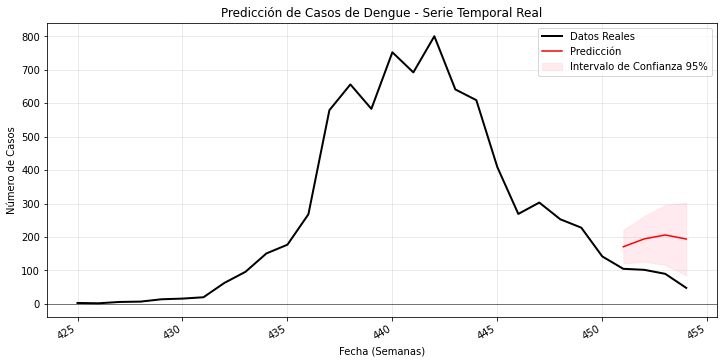

Error Absoluto Medio (MAE): 105.14 casos
Raíz del Error Cuadrático Medio (RMSE): 109.21 casos
Error Porcentual Absoluto Medio (MAPE): 146.68%


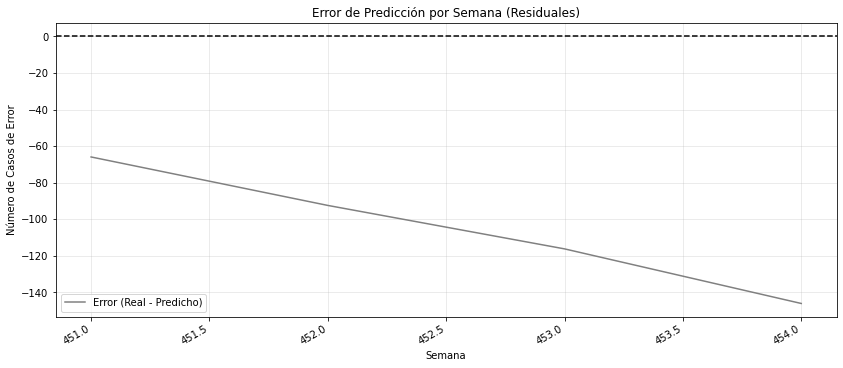

In [28]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX

model_final = SARIMAX(train_y, 
                       
                      order=(2, 1, 5), 
                      seasonal_order=(1, 1, 1, 52),
                      enforce_stationarity=False,
                      enforce_invertibility=False)
results_final = model_final.fit(disp=False)

forecast = results_final.get_forecast(steps=n_forecast )
forecast_df = forecast.summary_frame()
forecast_df.index = test_y.index

forecast_df['mean'] = np.clip(forecast_df['mean'], 0, None)
# forecast_df['mean_ci_lower'] = np.clip(forecast_df['mean_ci_lower'], 0, None)
# forecast_df['mean_ci_upper'] = np.clip(forecast_df['mean_ci_upper'], 0, None)

plt.figure(figsize=(12, 6))

plt.plot(y.index[-30:], y[-30:], label='Datos Reales', color='black', linewidth=2)

plt.plot(test_y.index, forecast_df['mean'], label='Predicción', color='red')

plt.fill_between(forecast_df.index, 
                 forecast_df['mean_ci_lower'], 
                 forecast_df['mean_ci_upper'], 
                 color='pink', alpha=0.3, label='Intervalo de Confianza 95%')

plt.gcf().autofmt_xdate() 

plt.title('Predicción de Casos de Dengue - Serie Temporal Real')
plt.xlabel('Fecha (Semanas)')
plt.ylabel('Número de Casos')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axhline(0, color='black', linewidth=1, alpha=0.5) # Línea en el cero
plt.show()
y_true = test_y
y_pred = forecast_df['mean']

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_true, y_pred)

print(f"Error Absoluto Medio (MAE): {mae:.2f} casos")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse:.2f} casos")
print(f"Error Porcentual Absoluto Medio (MAPE): {mape*100:.2f}%")

error_semanal = y_true - y_pred

plt.figure(figsize=(14, 6))
plt.plot(error_semanal.index, error_semanal, color='gray', label='Error (Real - Predicho)')
plt.axhline(0, color='black', linestyle='--', linewidth=1.5)
plt.title('Error de Predicción por Semana (Residuales)')
plt.xlabel('Semana')
plt.ylabel('Número de Casos de Error')
plt.legend()
plt.grid(True, alpha=0.3)
plt.gcf().autofmt_xdate()
plt.show()

# Cienfuegos

Index(['Año_x', 'Semana Estadística', 'Fecha', 'Casos_Dengue', 'Temp_Med',
       'Hum_Rel', 'Precip', 'Año_y', 'Mes'],
      dtype='object')


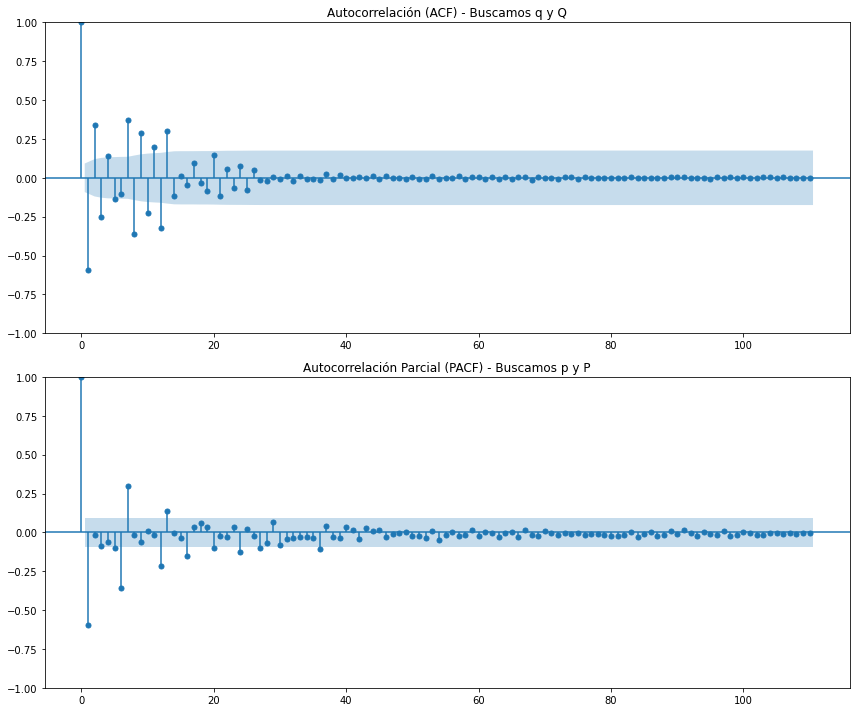

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import pandas as pd
import os

nombre_provincia = 'Cienfuegos'

carpeta_salida = 'dataframes_provincias'
nombre_archivo = f'{nombre_provincia.replace(" ", "_")}.csv'
ruta_completa = os.path.join(carpeta_salida, nombre_archivo)

df= pd.read_csv(ruta_completa)

df= df.drop(['Unnamed: 0', "Provincias"], axis=1)
print(df.columns)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

serie_diferenciada = df["Casos_Dengue"].diff().dropna()

# ACF: Ayuda a identificar q (MA) y Q (SMA)
plot_acf(serie_diferenciada, lags=110, ax=ax1)
ax1.set_title('Autocorrelación (ACF) - Buscamos q y Q')

# PACF: Ayuda a identificar p (AR) y P (SAR)
plot_pacf(serie_diferenciada, lags=110, ax=ax2)
ax2.set_title('Autocorrelación Parcial (PACF) - Buscamos p y P')

plt.tight_layout()
plt.show()

In [30]:
import itertools
import statsmodels.api as sm

p =  [0,1,2]
q=[0,1,2,3]
d = [1]
P = D = Q = range(0, 2) # Estacionales 0 o 1
s = 52 

pdq = list(itertools.product(p, d, q))
seasonal_pdq = [(x[0], x[1], x[2], s) for x in list(itertools.product(P, D, Q))]
y = df["Casos_Dengue"]

n_forecast = 4

train_y = y[:-n_forecast]
 
test_y = y[-n_forecast:]
 

mejores_params = None
mejor_aic = float("inf")

for param in pdq:
    for param_seasonal in seasonal_pdq:
        try:
            mod = sm.tsa.statespace.SARIMAX(train_y,
                                            
                                            order=param,
                                            seasonal_order=param_seasonal,
                                            enforce_stationarity=False,
                                            enforce_invertibility=False)
            results = mod.fit(disp=False)
            print(param,param_seasonal,results.aic)

            if results.aic < mejor_aic:
                mejor_aic = results.aic
                mejores_params = (param, param_seasonal)
                
        except:
            continue

print(f"Mejor SARIMA: {mejores_params} con AIC: {mejor_aic}")

(0, 1, 0) (0, 0, 0, 52) 5102.948649657931
(0, 1, 0) (0, 0, 1, 52) 3580.6575521204895
(0, 1, 0) (0, 1, 0, 52) 4592.5765668878485
(0, 1, 0) (0, 1, 1, 52) 3358.4233621245135
(0, 1, 0) (1, 0, 0, 52) 3588.728122266403
(0, 1, 0) (1, 0, 1, 52) 3582.5295845056703
(0, 1, 0) (1, 1, 0, 52) 3369.1038441654337
(0, 1, 0) (1, 1, 1, 52) 3304.439868502666
(0, 1, 1) (0, 0, 0, 52) 4906.442604241954
(0, 1, 1) (0, 0, 1, 52) 3528.42177123443
(0, 1, 1) (0, 1, 0, 52) 4463.338139800693
(0, 1, 1) (0, 1, 1, 52) 3295.898189161345
(0, 1, 1) (1, 0, 0, 52) 3544.3752515392616
(0, 1, 1) (1, 0, 1, 52) 3530.305390818873
(0, 1, 1) (1, 1, 0, 52) 3315.3770302046514
(0, 1, 1) (1, 1, 1, 52) 3258.2998269865247
(0, 1, 2) (0, 0, 0, 52) 4888.439202902853
(0, 1, 2) (0, 0, 1, 52) 3513.782443746608
(0, 1, 2) (0, 1, 0, 52) 4440.452989103866
(0, 1, 2) (0, 1, 1, 52) 3277.65436375729
(0, 1, 2) (1, 0, 0, 52) 3538.672313319591
(0, 1, 2) (1, 0, 1, 52) 3515.7380902811
(0, 1, 2) (1, 1, 0, 52) 3306.2593203336723
(0, 1, 2) (1, 1, 1, 52) 3155.

/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(1, 1, 1) (0, 0, 1, 52) 3528.7972237984704
(1, 1, 1) (0, 1, 0, 52) 4433.77321910998
(1, 1, 1) (0, 1, 1, 52) 3342.3108631238374
(1, 1, 1) (1, 0, 0, 52) 3571.7009738983134
(1, 1, 1) (1, 0, 1, 52) 3565.59829484247
(1, 1, 1) (1, 1, 0, 52) 3348.854206292821
(1, 1, 1) (1, 1, 1, 52) 3161.927844273432
(1, 1, 2) (0, 0, 0, 52) 4869.130165852677
(1, 1, 2) (0, 0, 1, 52) 3500.995613908036
(1, 1, 2) (0, 1, 0, 52) 4425.336727667356
(1, 1, 2) (0, 1, 1, 52) 3269.2219566729573
(1, 1, 2) (1, 0, 0, 52) 3517.695113387868
(1, 1, 2) (1, 0, 1, 52) 3502.962249336558
(1, 1, 2) (1, 1, 0, 52) 3287.2903023480626
(1, 1, 2) (1, 1, 1, 52) 3157.3851964165365
(1, 1, 3) (0, 0, 0, 52) 4840.487486643235
(1, 1, 3) (0, 0, 1, 52) 3509.633835371157
(1, 1, 3) (0, 1, 0, 52) 4404.157107259834
(1, 1, 3) (0, 1, 1, 52) 3272.1843904303537
(1, 1, 3) (1, 0, 0, 52) 3502.302810980369
(1, 1, 3) (1, 0, 1, 52) 3479.6879771443973
(1, 1, 3) (1, 1, 0, 52) 3296.4710192764514
(1, 1, 3) (1, 1, 1, 52) 3221.1850700391933
(2, 1, 0) (0, 0, 0, 52) 48

/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(2, 1, 1) (0, 0, 1, 52) 3494.697119142297
(2, 1, 1) (0, 1, 0, 52) 4419.583338415876
(2, 1, 1) (0, 1, 1, 52) 3259.3342231786255


...

(2, 1, 3) (1, 0, 0, 52) 3495.0260162862824


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(2, 1, 3) (1, 0, 1, 52) 3480.2589684116238
(2, 1, 3) (1, 1, 0, 52) 3260.52551974616


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(2, 1, 3) (1, 1, 1, 52) 3172.2821849730485
Mejor SARIMA: ((2, 1, 2), (1, 1, 1, 52)) con AIC: 3131.4659217779836


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


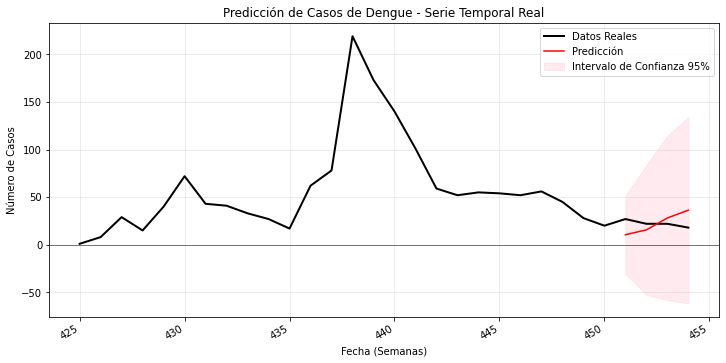

Error Absoluto Medio (MAE): 11.83 casos
Raíz del Error Cuadrático Medio (RMSE): 13.09 casos
Error Porcentual Absoluto Medio (MAPE): 54.93%


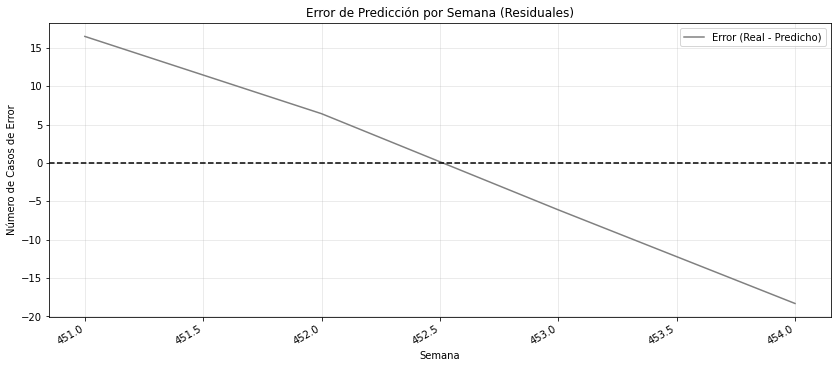

In [31]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX

model_final = SARIMAX(train_y, 
                       
                      order=(2,1,2), 
                      seasonal_order=(1, 1, 1, 52),
                      enforce_stationarity=False,
                      enforce_invertibility=False)
results_final = model_final.fit(disp=False)

forecast = results_final.get_forecast(steps=n_forecast )
forecast_df = forecast.summary_frame()
forecast_df.index = test_y.index

forecast_df['mean'] = np.clip(forecast_df['mean'], 0, None)
# forecast_df['mean_ci_lower'] = np.clip(forecast_df['mean_ci_lower'], 0, None)
# forecast_df['mean_ci_upper'] = np.clip(forecast_df['mean_ci_upper'], 0, None)

plt.figure(figsize=(12, 6))

plt.plot(y.index[-30:], y[-30:], label='Datos Reales', color='black', linewidth=2)

plt.plot(test_y.index, forecast_df['mean'], label='Predicción', color='red')

plt.fill_between(forecast_df.index, 
                 forecast_df['mean_ci_lower'], 
                 forecast_df['mean_ci_upper'], 
                 color='pink', alpha=0.3, label='Intervalo de Confianza 95%')

plt.gcf().autofmt_xdate() 

plt.title('Predicción de Casos de Dengue - Serie Temporal Real')
plt.xlabel('Fecha (Semanas)')
plt.ylabel('Número de Casos')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axhline(0, color='black', linewidth=1, alpha=0.5) # Línea en el cero
plt.show()
y_true = test_y
y_pred = forecast_df['mean']

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_true, y_pred)

print(f"Error Absoluto Medio (MAE): {mae:.2f} casos")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse:.2f} casos")
print(f"Error Porcentual Absoluto Medio (MAPE): {mape*100:.2f}%")

error_semanal = y_true - y_pred

plt.figure(figsize=(14, 6))
plt.plot(error_semanal.index, error_semanal, color='gray', label='Error (Real - Predicho)')
plt.axhline(0, color='black', linestyle='--', linewidth=1.5)
plt.title('Error de Predicción por Semana (Residuales)')
plt.xlabel('Semana')
plt.ylabel('Número de Casos de Error')
plt.legend()
plt.grid(True, alpha=0.3)
plt.gcf().autofmt_xdate()
plt.show()

# Villa Clara

Index(['Año_x', 'Semana Estadística', 'Fecha', 'Casos_Dengue', 'Temp_Med',
       'Hum_Rel', 'Precip', 'Año_y', 'Mes'],
      dtype='object')


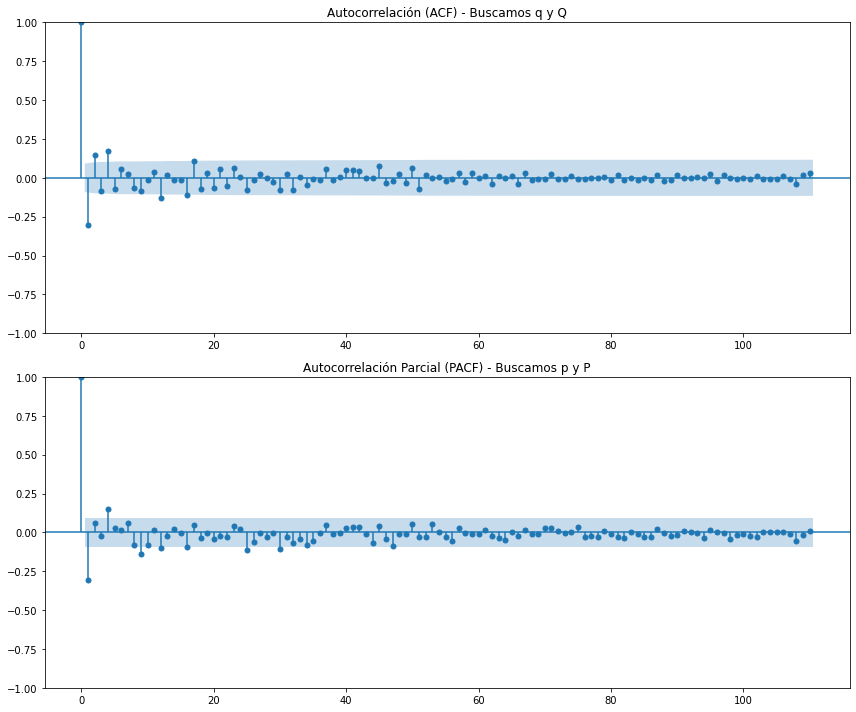

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import pandas as pd
import os

nombre_provincia = 'Villa_Clara'

carpeta_salida = 'dataframes_provincias'
nombre_archivo = f'{nombre_provincia.replace(" ", "_")}.csv'
ruta_completa = os.path.join(carpeta_salida, nombre_archivo)

df= pd.read_csv(ruta_completa)

df= df.drop(['Unnamed: 0', "Provincias"], axis=1)
print(df.columns)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

serie_diferenciada = df["Casos_Dengue"].diff().dropna()

# ACF: Ayuda a identificar q (MA) y Q (SMA)
plot_acf(serie_diferenciada, lags=110, ax=ax1)
ax1.set_title('Autocorrelación (ACF) - Buscamos q y Q')

# PACF: Ayuda a identificar p (AR) y P (SAR)
plot_pacf(serie_diferenciada, lags=110, ax=ax2)
ax2.set_title('Autocorrelación Parcial (PACF) - Buscamos p y P')

plt.tight_layout()
plt.show()

In [33]:
import itertools
import statsmodels.api as sm

p =  [0,1,2]
q=[0,1,2,3,4]
d = [1]
P = D = Q = range(0, 2) # Estacionales 0 o 1
s = 52 

pdq = list(itertools.product(p, d, q))
seasonal_pdq = [(x[0], x[1], x[2], s) for x in list(itertools.product(P, D, Q))]
y = df["Casos_Dengue"]

n_forecast = 4

train_y = y[:-n_forecast]
 
test_y = y[-n_forecast:]
 

mejores_params = None
mejor_aic = float("inf")

for param in pdq:
    for param_seasonal in seasonal_pdq:
        try:
            mod = sm.tsa.statespace.SARIMAX(train_y,
                                            
                                            order=param,
                                            seasonal_order=param_seasonal,
                                            enforce_stationarity=False,
                                            enforce_invertibility=False)
            results = mod.fit(disp=False)
            print(param,param_seasonal,results.aic)

            if results.aic < mejor_aic:
                mejor_aic = results.aic
                mejores_params = (param, param_seasonal)
                
        except:
            continue

print(f"Mejor SARIMA: {mejores_params} con AIC: {mejor_aic}")

(0, 1, 0) (0, 0, 0, 52) 4976.023685217033
(0, 1, 0) (0, 0, 1, 52) 4131.16190891576
(0, 1, 0) (0, 1, 0, 52) 4516.862064353525
(0, 1, 0) (0, 1, 1, 52) 3746.815710363513
(0, 1, 0) (1, 0, 0, 52) 4140.567170951399
(0, 1, 0) (1, 0, 1, 52) 4132.276083550717
(0, 1, 0) (1, 1, 0, 52) 3759.9023157006395
(0, 1, 0) (1, 1, 1, 52) 3720.5343701813463
(0, 1, 1) (0, 0, 0, 52) 4921.546142099393
(0, 1, 1) (0, 0, 1, 52) 4120.69276424666
(0, 1, 1) (0, 1, 0, 52) 4488.228274251172
(0, 1, 1) (0, 1, 1, 52) 3736.5754878109083
(0, 1, 1) (1, 0, 0, 52) 4139.608337118434
(0, 1, 1) (1, 0, 1, 52) 4122.024980275878
(0, 1, 1) (1, 1, 0, 52) 3760.8179445454116
(0, 1, 1) (1, 1, 1, 52) 3708.1704489868816
(0, 1, 2) (0, 0, 0, 52) 4900.697623576052
(0, 1, 2) (0, 0, 1, 52) 4112.108615485034
(0, 1, 2) (0, 1, 0, 52) 4472.569006108814
(0, 1, 2) (0, 1, 1, 52) 3726.370948020286
(0, 1, 2) (1, 0, 0, 52) 4140.579455404415
(0, 1, 2) (1, 0, 1, 52) 4113.6169352149955
(0, 1, 2) (1, 1, 0, 52) 3760.48874190903
(0, 1, 2) (1, 1, 1, 52) 3699.78

/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(1, 1, 4) (0, 1, 1, 52) 3702.8083904592822
(1, 1, 4) (1, 0, 0, 52) 4127.764509408134
(1, 1, 4) (1, 0, 1, 52) 4091.6724013761022
(1, 1, 4) (1, 1, 0, 52) 3747.0221144350326
(1, 1, 4) (1, 1, 1, 52) 3677.892250019694
(2, 1, 0) (0, 0, 0, 52) 4911.710783113696
(2, 1, 0) (0, 0, 1, 52) 4131.763107657561
(2, 1, 0) (0, 1, 0, 52) 4486.238280304872
(2, 1, 0) (0, 1, 1, 52) 3747.5030705954478
(2, 1, 0) (1, 0, 0, 52) 4121.875443506135
(2, 1, 0) (1, 0, 1, 52) 4123.805177516704
(2, 1, 0) (1, 1, 0, 52) 3739.421632647725
(2, 1, 0) (1, 1, 1, 52) 3709.0421139720083
(2, 1, 1) (0, 0, 0, 52) 4909.723039781517
(2, 1, 1) (0, 0, 1, 52) 4121.724320346828
(2, 1, 1) (0, 1, 0, 52) 4485.992405834536
(2, 1, 1) (0, 1, 1, 52) 3735.583404719807
(2, 1, 1) (1, 0, 0, 52) 4120.8392265838265
(2, 1, 1) (1, 0, 1, 52) 4122.751073064115
(2, 1, 1) (1, 1, 0, 52) 3739.777558081248
(2, 1, 1) (1, 1, 1, 52) 3707.3949912310354
(2, 1, 2) (0, 0, 0, 52) 4900.232466867789


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(2, 1, 2) (0, 0, 1, 52) 4085.3251798641204
(2, 1, 2) (0, 1, 0, 52) 4470.41664507419
(2, 1, 2) (0, 1, 1, 52) 3721.8288983660505
(2, 1, 2) (1, 0, 0, 52) 4099.313637062877
(2, 1, 2) (1, 0, 1, 52) 4086.9562522966276
(2, 1, 2) (1, 1, 0, 52) 3732.5058609008884


...

(2, 1, 4) (1, 0, 0, 52) 4118.062819103214
(2, 1, 4) (1, 0, 1, 52) 4091.004809332937


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(2, 1, 4) (1, 1, 0, 52) 3738.836740571091


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(2, 1, 4) (1, 1, 1, 52) 3705.709561021782
Mejor SARIMA: ((1, 1, 4), (1, 1, 1, 52)) con AIC: 3677.892250019694


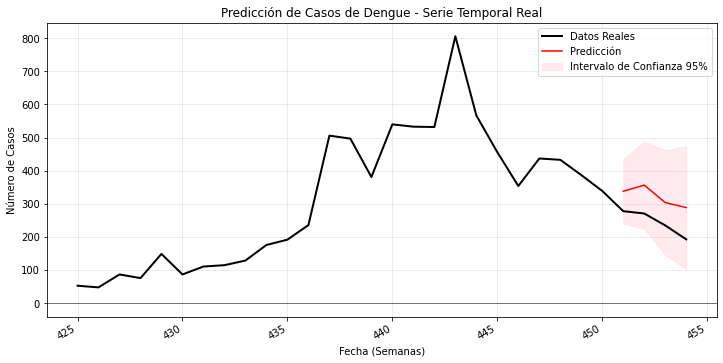

Error Absoluto Medio (MAE): 77.60 casos
Raíz del Error Cuadrático Medio (RMSE): 78.85 casos
Error Porcentual Absoluto Medio (MAPE): 33.04%


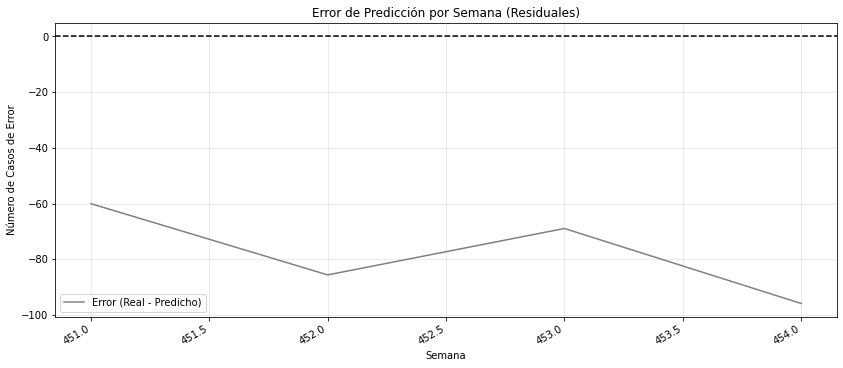

In [34]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX

model_final = SARIMAX(train_y, 
                       
                      order=(1, 1, 4), 
                      seasonal_order=(1, 1, 1, 52),
                      enforce_stationarity=False,
                      enforce_invertibility=False)
results_final = model_final.fit(disp=False)

forecast = results_final.get_forecast(steps=n_forecast )
forecast_df = forecast.summary_frame()
forecast_df.index = test_y.index

forecast_df['mean'] = np.clip(forecast_df['mean'], 0, None)
# forecast_df['mean_ci_lower'] = np.clip(forecast_df['mean_ci_lower'], 0, None)
# forecast_df['mean_ci_upper'] = np.clip(forecast_df['mean_ci_upper'], 0, None)

plt.figure(figsize=(12, 6))

plt.plot(y.index[-30:], y[-30:], label='Datos Reales', color='black', linewidth=2)

plt.plot(test_y.index, forecast_df['mean'], label='Predicción', color='red')

plt.fill_between(forecast_df.index, 
                 forecast_df['mean_ci_lower'], 
                 forecast_df['mean_ci_upper'], 
                 color='pink', alpha=0.3, label='Intervalo de Confianza 95%')

plt.gcf().autofmt_xdate() 

plt.title('Predicción de Casos de Dengue - Serie Temporal Real')
plt.xlabel('Fecha (Semanas)')
plt.ylabel('Número de Casos')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axhline(0, color='black', linewidth=1, alpha=0.5) # Línea en el cero
plt.show()
y_true = test_y
y_pred = forecast_df['mean']

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_true, y_pred)

print(f"Error Absoluto Medio (MAE): {mae:.2f} casos")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse:.2f} casos")
print(f"Error Porcentual Absoluto Medio (MAPE): {mape*100:.2f}%")

error_semanal = y_true - y_pred

plt.figure(figsize=(14, 6))
plt.plot(error_semanal.index, error_semanal, color='gray', label='Error (Real - Predicho)')
plt.axhline(0, color='black', linestyle='--', linewidth=1.5)
plt.title('Error de Predicción por Semana (Residuales)')
plt.xlabel('Semana')
plt.ylabel('Número de Casos de Error')
plt.legend()
plt.grid(True, alpha=0.3)
plt.gcf().autofmt_xdate()
plt.show()

# Santi Spiritus

Index(['Año_x', 'Semana Estadística', 'Fecha', 'Casos_Dengue', 'Temp_Med',
       'Hum_Rel', 'Precip', 'Año_y', 'Mes'],
      dtype='object')


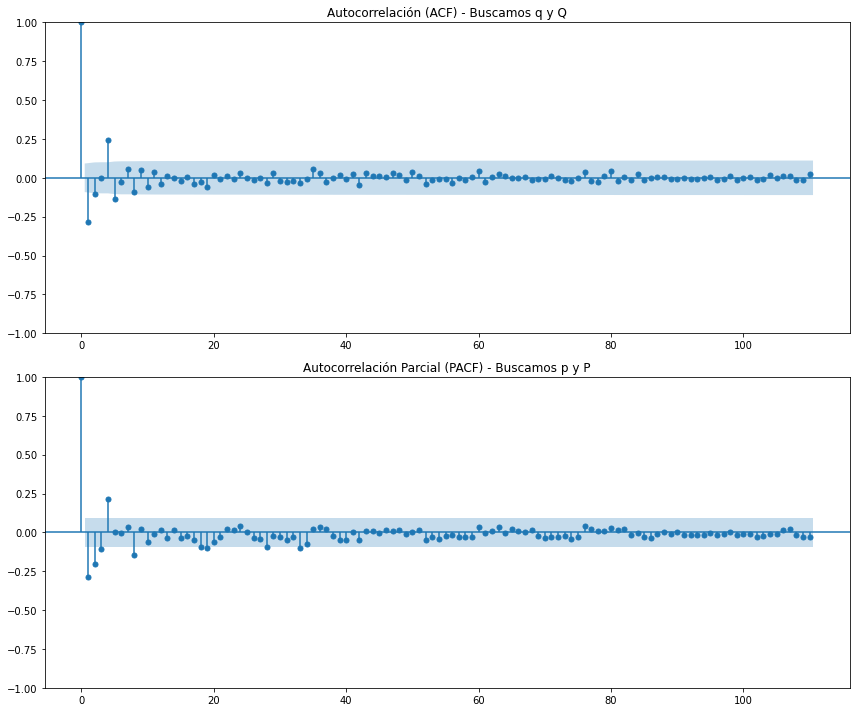

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import pandas as pd
import os

nombre_provincia = 'Sancti_Spíritus'

carpeta_salida = 'dataframes_provincias'
nombre_archivo = f'{nombre_provincia.replace(" ", "_")}.csv'
ruta_completa = os.path.join(carpeta_salida, nombre_archivo)

df= pd.read_csv(ruta_completa)

df= df.drop(['Unnamed: 0', "Provincias"], axis=1)
print(df.columns)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

serie_diferenciada = df["Casos_Dengue"].diff().dropna()

# ACF: Ayuda a identificar q (MA) y Q (SMA)
plot_acf(serie_diferenciada, lags=110, ax=ax1)
ax1.set_title('Autocorrelación (ACF) - Buscamos q y Q')

# PACF: Ayuda a identificar p (AR) y P (SAR)
plot_pacf(serie_diferenciada, lags=110, ax=ax2)
ax2.set_title('Autocorrelación Parcial (PACF) - Buscamos p y P')

plt.tight_layout()
plt.show()

In [36]:
import itertools
import statsmodels.api as sm

p =  [0,1,2,3,4]
q=[0,1,2]
d = [1]
P = D = Q = range(0, 2) # Estacionales 0 o 1
s = 52 

pdq = list(itertools.product(p, d, q))
seasonal_pdq = [(x[0], x[1], x[2], s) for x in list(itertools.product(P, D, Q))]
y = df["Casos_Dengue"]

n_forecast = 4

train_y = y[:-n_forecast]
 
test_y = y[-n_forecast:]
 

mejores_params = None
mejor_aic = float("inf")

for param in pdq:
    for param_seasonal in seasonal_pdq:
        try:
            mod = sm.tsa.statespace.SARIMAX(train_y,
                                            
                                            order=param,
                                            seasonal_order=param_seasonal,
                                            enforce_stationarity=False,
                                            enforce_invertibility=False)
            results = mod.fit(disp=False)
            print(param,param_seasonal,results.aic)

            if results.aic < mejor_aic:
                mejor_aic = results.aic
                mejores_params = (param, param_seasonal)
                
        except:
            continue

print(f"Mejor SARIMA: {mejores_params} con AIC: {mejor_aic}")

(0, 1, 0) (0, 0, 0, 52) 4709.363720097075
(0, 1, 0) (0, 0, 1, 52) 3875.8219167745856
(0, 1, 0) (0, 1, 0, 52) 4266.462066052032
(0, 1, 0) (0, 1, 1, 52) 3488.8832503151743
(0, 1, 0) (1, 0, 0, 52) 3885.011851886332
(0, 1, 0) (1, 0, 1, 52) 3877.7222788285503
(0, 1, 0) (1, 1, 0, 52) 3496.70141598144
(0, 1, 0) (1, 1, 1, 52) 3468.077119299599
(0, 1, 1) (0, 0, 0, 52) 4638.248708232524
(0, 1, 1) (0, 0, 1, 52) 3862.951058053769
(0, 1, 1) (0, 1, 0, 52) 4219.675042273575
(0, 1, 1) (0, 1, 1, 52) 3478.4407910415343
(0, 1, 1) (1, 0, 0, 52) 3881.002693655462
(0, 1, 1) (1, 0, 1, 52) 3864.8646227845397
(0, 1, 1) (1, 1, 0, 52) 3495.3088059506836
(0, 1, 1) (1, 1, 1, 52) 3456.8025738994897
(0, 1, 2) (0, 0, 0, 52) 4629.91517751025
(0, 1, 2) (0, 0, 1, 52) 3856.120910221378
(0, 1, 2) (0, 1, 0, 52) 4211.269748316147
(0, 1, 2) (0, 1, 1, 52) 3471.1949448662635
(0, 1, 2) (1, 0, 0, 52) 3882.9058854852747
(0, 1, 2) (1, 0, 1, 52) 3858.033367872862
(0, 1, 2) (1, 1, 0, 52) 3497.1344066847823
(0, 1, 2) (1, 1, 1, 52) 34

/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(3, 1, 2) (1, 1, 1, 52) 3444.7882213177186
(4, 1, 0) (0, 0, 0, 52) 4595.4227212077
(4, 1, 0) (0, 0, 1, 52) 3875.7488918122326
(4, 1, 0) (0, 1, 0, 52) 4185.545003053961
(4, 1, 0) (0, 1, 1, 52) 3490.1605328520227
(4, 1, 0) (1, 0, 0, 52) 3849.883059994626
(4, 1, 0) (1, 0, 1, 52) 3851.38228432709
(4, 1, 0) (1, 1, 0, 52) 3461.1403910689587
(4, 1, 0) (1, 1, 1, 52) 3439.925125472836
(4, 1, 1) (0, 0, 0, 52) 4597.405641686946
(4, 1, 1) (0, 0, 1, 52) 3868.689010896521
(4, 1, 1) (0, 1, 0, 52) 4187.447818741604
(4, 1, 1) (0, 1, 1, 52) 3481.978521985152
(4, 1, 1) (1, 0, 0, 52) 3851.602085839625
(4, 1, 1) (1, 0, 1, 52) 3853.0910739720853
(4, 1, 1) (1, 1, 0, 52) 3462.827129846678
(4, 1, 1) (1, 1, 1, 52) 3441.8625831938657
(4, 1, 2) (0, 0, 0, 52) 4599.381007297288
(4, 1, 2) (0, 0, 1, 52) 3861.771290925811
(4, 1, 2) (0, 1, 0, 52) 4189.420295084405
(4, 1, 2) (0, 1, 1, 52) 3465.4240122516303
(4, 1, 2) (1, 0, 0, 52) 3853.4060410251886
(4, 1, 2) (1, 0, 1, 52) 3854.9113294229637
(4, 1, 2) (1, 1, 0, 52) 3455

/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(4, 1, 2) (1, 1, 1, 52) 3444.628754217816
Mejor SARIMA: ((4, 1, 0), (1, 1, 1, 52)) con AIC: 3439.925125472836


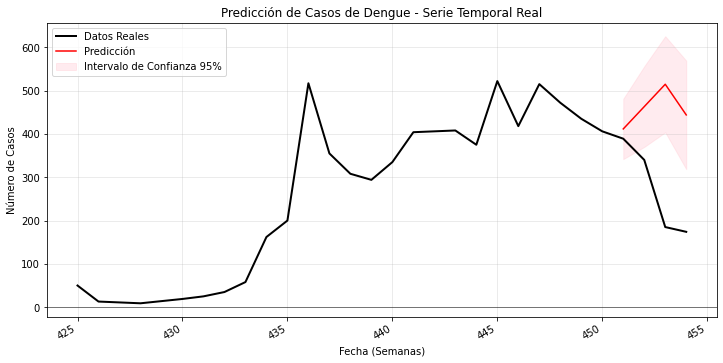

Error Absoluto Medio (MAE): 186.32 casos
Raíz del Error Cuadrático Medio (RMSE): 222.05 casos
Error Porcentual Absoluto Medio (MAPE): 93.84%


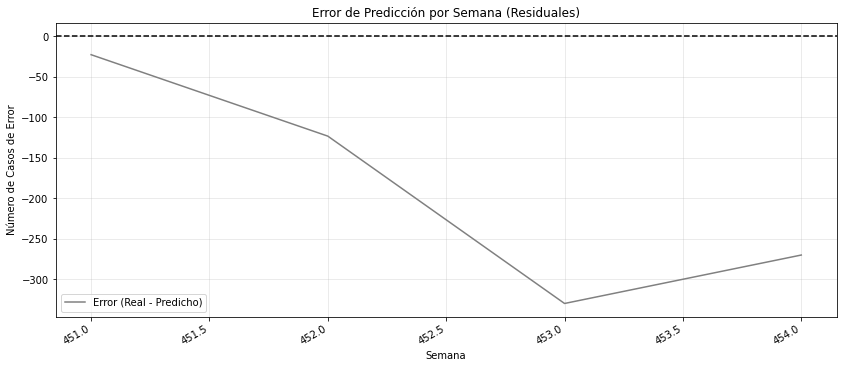

In [37]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX

model_final = SARIMAX(train_y, 
                       
                      order=(4, 1, 0), 
                      seasonal_order=(1, 1, 1, 52),
                      enforce_stationarity=False,
                      enforce_invertibility=False)
results_final = model_final.fit(disp=False)

forecast = results_final.get_forecast(steps=n_forecast )
forecast_df = forecast.summary_frame()
forecast_df.index = test_y.index

forecast_df['mean'] = np.clip(forecast_df['mean'], 0, None)
# forecast_df['mean_ci_lower'] = np.clip(forecast_df['mean_ci_lower'], 0, None)
# forecast_df['mean_ci_upper'] = np.clip(forecast_df['mean_ci_upper'], 0, None)

plt.figure(figsize=(12, 6))

plt.plot(y.index[-30:], y[-30:], label='Datos Reales', color='black', linewidth=2)

plt.plot(test_y.index, forecast_df['mean'], label='Predicción', color='red')

plt.fill_between(forecast_df.index, 
                 forecast_df['mean_ci_lower'], 
                 forecast_df['mean_ci_upper'], 
                 color='pink', alpha=0.3, label='Intervalo de Confianza 95%')

plt.gcf().autofmt_xdate() 

plt.title('Predicción de Casos de Dengue - Serie Temporal Real')
plt.xlabel('Fecha (Semanas)')
plt.ylabel('Número de Casos')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axhline(0, color='black', linewidth=1, alpha=0.5) # Línea en el cero
plt.show()
y_true = test_y
y_pred = forecast_df['mean']

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_true, y_pred)

print(f"Error Absoluto Medio (MAE): {mae:.2f} casos")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse:.2f} casos")
print(f"Error Porcentual Absoluto Medio (MAPE): {mape*100:.2f}%")

error_semanal = y_true - y_pred

plt.figure(figsize=(14, 6))
plt.plot(error_semanal.index, error_semanal, color='gray', label='Error (Real - Predicho)')
plt.axhline(0, color='black', linestyle='--', linewidth=1.5)
plt.title('Error de Predicción por Semana (Residuales)')
plt.xlabel('Semana')
plt.ylabel('Número de Casos de Error')
plt.legend()
plt.grid(True, alpha=0.3)
plt.gcf().autofmt_xdate()
plt.show()

# Ciego de Avila

Index(['Año_x', 'Semana Estadística', 'Fecha', 'Casos_Dengue', 'Temp_Med',
       'Hum_Rel', 'Precip', 'Año_y', 'Mes'],
      dtype='object')


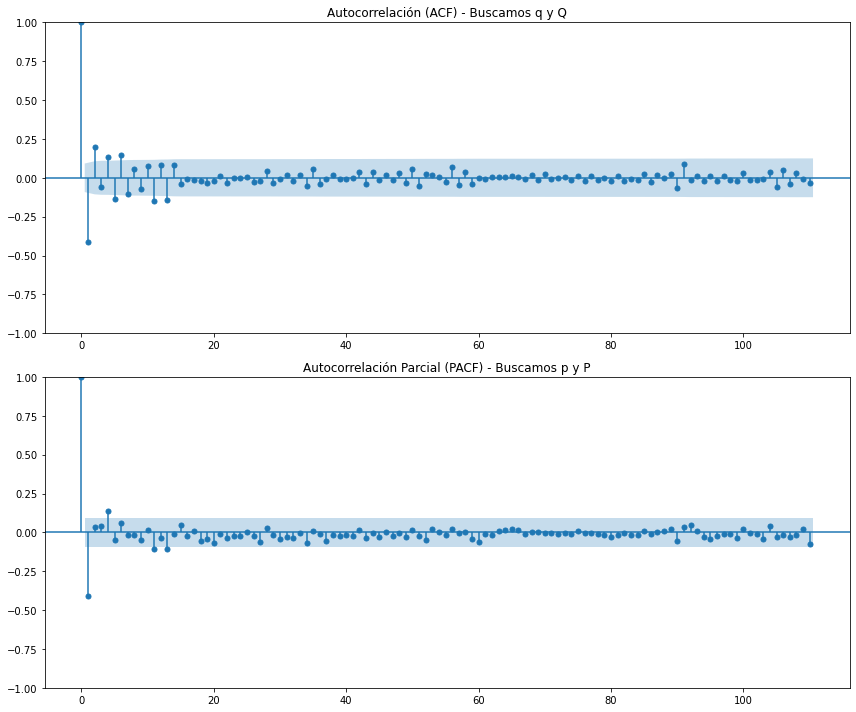

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import pandas as pd
import os

nombre_provincia = 'Ciego_de_Ávila'

carpeta_salida = 'dataframes_provincias'
nombre_archivo = f'{nombre_provincia.replace(" ", "_")}.csv'
ruta_completa = os.path.join(carpeta_salida, nombre_archivo)

df= pd.read_csv(ruta_completa)

df= df.drop(['Unnamed: 0', "Provincias"], axis=1)
print(df.columns)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

serie_diferenciada = df["Casos_Dengue"].diff().dropna()

# ACF: Ayuda a identificar q (MA) y Q (SMA)
plot_acf(serie_diferenciada, lags=110, ax=ax1)
ax1.set_title('Autocorrelación (ACF) - Buscamos q y Q')

# PACF: Ayuda a identificar p (AR) y P (SAR)
plot_pacf(serie_diferenciada, lags=110, ax=ax2)
ax2.set_title('Autocorrelación Parcial (PACF) - Buscamos p y P')

plt.tight_layout()
plt.show()

In [39]:
import itertools
import statsmodels.api as sm

p =  [0,1]
q=[0,1,2]
d = [1]
P = D = Q = range(0, 2) # Estacionales 0 o 1
s = 52 

pdq = list(itertools.product(p, d, q))
seasonal_pdq = [(x[0], x[1], x[2], s) for x in list(itertools.product(P, D, Q))]
y = df["Casos_Dengue"]

n_forecast = 4

train_y = y[:-n_forecast]
 
test_y = y[-n_forecast:]
 

mejores_params = None
mejor_aic = float("inf")

for param in pdq:
    for param_seasonal in seasonal_pdq:
        try:
            mod = sm.tsa.statespace.SARIMAX(train_y,
                                            
                                            order=param,
                                            seasonal_order=param_seasonal,
                                            enforce_stationarity=False,
                                            enforce_invertibility=False)
            results = mod.fit(disp=False)
            print(param,param_seasonal,results.aic)

            if results.aic < mejor_aic:
                mejor_aic = results.aic
                mejores_params = (param, param_seasonal)
                
        except:
            continue

print(f"Mejor SARIMA: {mejores_params} con AIC: {mejor_aic}")

(0, 1, 0) (0, 0, 0, 52) 4635.258521439612
(0, 1, 0) (0, 0, 1, 52) 3998.2529495646127
(0, 1, 0) (0, 1, 0, 52) 4274.957987427933
(0, 1, 0) (0, 1, 1, 52) 3571.863744008594
(0, 1, 0) (1, 0, 0, 52) 4007.2816170055657
(0, 1, 0) (1, 0, 1, 52) 4000.186183588586
(0, 1, 0) (1, 1, 0, 52) 3614.925794073187
(0, 1, 0) (1, 1, 1, 52) 3550.6649537441326
(0, 1, 1) (0, 0, 0, 52) 4560.507101802531
(0, 1, 1) (0, 0, 1, 52) 3949.3775858412228
(0, 1, 1) (0, 1, 0, 52) 4225.892501991022
(0, 1, 1) (0, 1, 1, 52) 3531.436932268089
(0, 1, 1) (1, 0, 0, 52) 3967.298818332064
(0, 1, 1) (1, 0, 1, 52) 3951.3414987530414
(0, 1, 1) (1, 1, 0, 52) 3590.820352321676
(0, 1, 1) (1, 1, 1, 52) 3512.348051851725
(0, 1, 2) (0, 0, 0, 52) 4527.412739092728
(0, 1, 2) (0, 0, 1, 52) 3909.8383851358285
(0, 1, 2) (0, 1, 0, 52) 4196.830122494413
(0, 1, 2) (0, 1, 1, 52) 3502.2928781199553
(0, 1, 2) (1, 0, 0, 52) 3936.4541684891947
(0, 1, 2) (1, 0, 1, 52) 3911.814514899832
(0, 1, 2) (1, 1, 0, 52) 3566.2712734580005
(0, 1, 2) (1, 1, 1, 52) 3

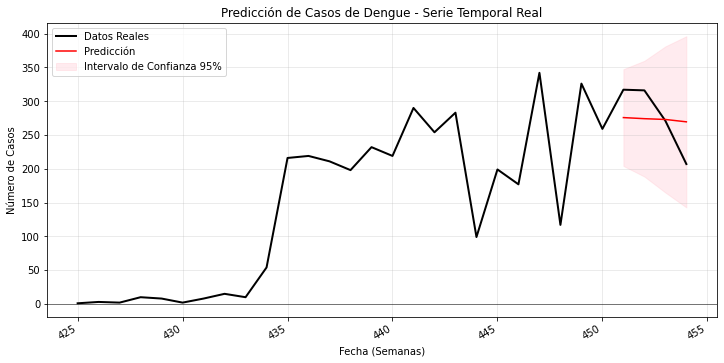

Error Absoluto Medio (MAE): 36.89 casos
Raíz del Error Cuadrático Medio (RMSE): 42.90 casos
Error Porcentual Absoluto Medio (MAPE): 14.29%


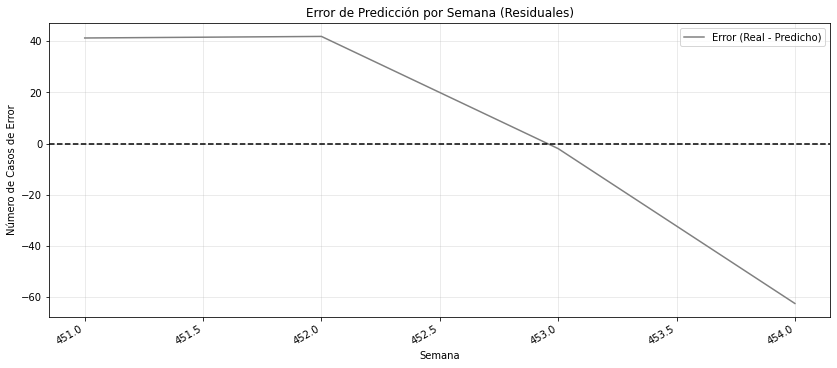

In [40]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX

model_final = SARIMAX(train_y, 
                       
                      order=(0, 1, 2), 
                      seasonal_order=(1, 1, 1, 52),
                      enforce_stationarity=False,
                      enforce_invertibility=False)
results_final = model_final.fit(disp=False)

forecast = results_final.get_forecast(steps=n_forecast )
forecast_df = forecast.summary_frame()
forecast_df.index = test_y.index

forecast_df['mean'] = np.clip(forecast_df['mean'], 0, None)
# forecast_df['mean_ci_lower'] = np.clip(forecast_df['mean_ci_lower'], 0, None)
# forecast_df['mean_ci_upper'] = np.clip(forecast_df['mean_ci_upper'], 0, None)

plt.figure(figsize=(12, 6))

plt.plot(y.index[-30:], y[-30:], label='Datos Reales', color='black', linewidth=2)

plt.plot(test_y.index, forecast_df['mean'], label='Predicción', color='red')

plt.fill_between(forecast_df.index, 
                 forecast_df['mean_ci_lower'], 
                 forecast_df['mean_ci_upper'], 
                 color='pink', alpha=0.3, label='Intervalo de Confianza 95%')

plt.gcf().autofmt_xdate() 

plt.title('Predicción de Casos de Dengue - Serie Temporal Real')
plt.xlabel('Fecha (Semanas)')
plt.ylabel('Número de Casos')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axhline(0, color='black', linewidth=1, alpha=0.5) # Línea en el cero
plt.show()
y_true = test_y
y_pred = forecast_df['mean']

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_true, y_pred)

print(f"Error Absoluto Medio (MAE): {mae:.2f} casos")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse:.2f} casos")
print(f"Error Porcentual Absoluto Medio (MAPE): {mape*100:.2f}%")

error_semanal = y_true - y_pred

plt.figure(figsize=(14, 6))
plt.plot(error_semanal.index, error_semanal, color='gray', label='Error (Real - Predicho)')
plt.axhline(0, color='black', linestyle='--', linewidth=1.5)
plt.title('Error de Predicción por Semana (Residuales)')
plt.xlabel('Semana')
plt.ylabel('Número de Casos de Error')
plt.legend()
plt.grid(True, alpha=0.3)
plt.gcf().autofmt_xdate()
plt.show()

# Camaguey

Index(['Año_x', 'Semana Estadística', 'Fecha', 'Casos_Dengue', 'Temp_Med',
       'Hum_Rel', 'Precip', 'Año_y', 'Mes'],
      dtype='object')


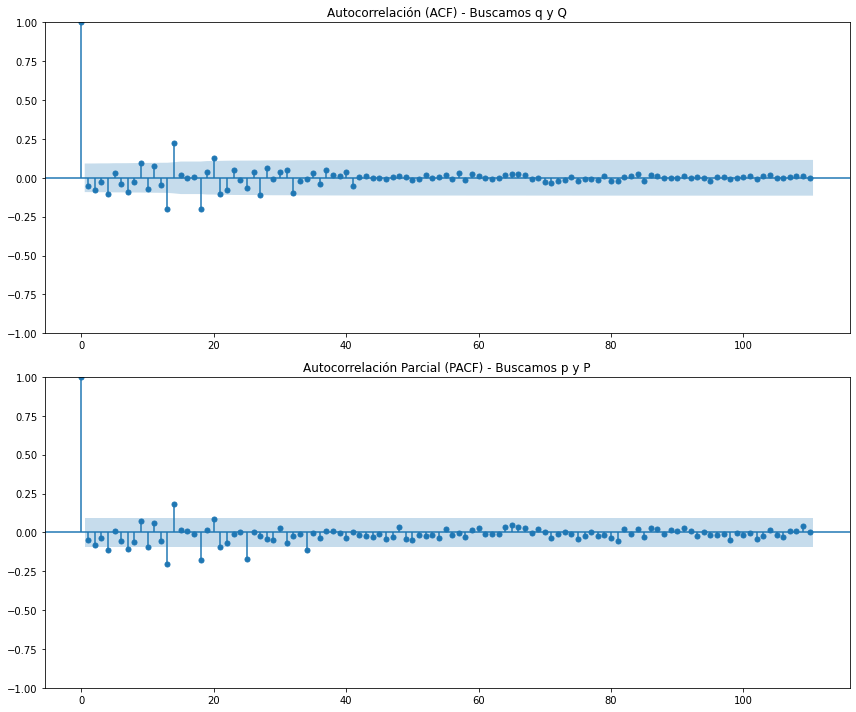

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import pandas as pd
import os

nombre_provincia = 'Camagüey'

carpeta_salida = 'dataframes_provincias'
nombre_archivo = f'{nombre_provincia.replace(" ", "_")}.csv'
ruta_completa = os.path.join(carpeta_salida, nombre_archivo)

df= pd.read_csv(ruta_completa)

df= df.drop(['Unnamed: 0', "Provincias"], axis=1)
print(df.columns)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

serie_diferenciada = df["Casos_Dengue"].diff().dropna()

# ACF: Ayuda a identificar q (MA) y Q (SMA)
plot_acf(serie_diferenciada, lags=110, ax=ax1)
ax1.set_title('Autocorrelación (ACF) - Buscamos q y Q')

# PACF: Ayuda a identificar p (AR) y P (SAR)
plot_pacf(serie_diferenciada, lags=110, ax=ax2)
ax2.set_title('Autocorrelación Parcial (PACF) - Buscamos p y P')

plt.tight_layout()
plt.show()

In [42]:
import itertools
import statsmodels.api as sm

p =  [0,1,2,3,4]
q=[0,1,2,3,4]
d = [1]
P = D = Q = range(0, 2) # Estacionales 0 o 1
s = 52 

pdq = list(itertools.product(p, d, q))
seasonal_pdq = [(x[0], x[1], x[2], s) for x in list(itertools.product(P, D, Q))]
y = df["Casos_Dengue"]

n_forecast = 4

train_y = y[:-n_forecast]
 
test_y = y[-n_forecast:]
 

mejores_params = None
mejor_aic = float("inf")

for param in pdq:
    for param_seasonal in seasonal_pdq:
        try:
            mod = sm.tsa.statespace.SARIMAX(train_y,
                                            
                                            order=param,
                                            seasonal_order=param_seasonal,
                                            enforce_stationarity=False,
                                            enforce_invertibility=False)
            results = mod.fit(disp=False)
            print(param,param_seasonal,results.aic)

            if results.aic < mejor_aic:
                mejor_aic = results.aic
                mejores_params = (param, param_seasonal)
                
        except:
            continue

print(f"Mejor SARIMA: {mejores_params} con AIC: {mejor_aic}")

(0, 1, 0) (0, 0, 0, 52) 5311.243248863026
(0, 1, 0) (0, 0, 1, 52) 4292.647787412648
(0, 1, 0) (0, 1, 0, 52) 4800.578019622695
(0, 1, 0) (0, 1, 1, 52) 3890.6427848650674
(0, 1, 0) (1, 0, 0, 52) 4302.808031537865
(0, 1, 0) (1, 0, 1, 52) 4294.595629497262
(0, 1, 0) (1, 1, 0, 52) 3902.226466861269
(0, 1, 0) (1, 1, 1, 52) 3853.815152864425
(0, 1, 1) (0, 0, 0, 52) 5300.957973721546
(0, 1, 1) (0, 0, 1, 52) 4271.547420945658
(0, 1, 1) (0, 1, 0, 52) 4791.395923272485
(0, 1, 1) (0, 1, 1, 52) 3871.5145617026064
(0, 1, 1) (1, 0, 0, 52) 4291.764101886031
(0, 1, 1) (1, 0, 1, 52) 4273.5104449473
(0, 1, 1) (1, 1, 0, 52) 3892.914617425894
(0, 1, 1) (1, 1, 1, 52) 3838.176487039711
(0, 1, 2) (0, 0, 0, 52) 5288.246007777747
(0, 1, 2) (0, 0, 1, 52) 4259.466460449135
(0, 1, 2) (0, 1, 0, 52) 4781.001130496345
(0, 1, 2) (0, 1, 1, 52) 3855.4639557936534
(0, 1, 2) (1, 0, 0, 52) 4289.731747327229
(0, 1, 2) (1, 0, 1, 52) 4261.435398262236
(0, 1, 2) (1, 1, 0, 52) 3886.743068479903
(0, 1, 2) (1, 1, 1, 52) 3825.1324

/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(1, 1, 2) (0, 0, 1, 52) 4263.343027396456
(1, 1, 2) (0, 1, 0, 52) 4763.633369985394
(1, 1, 2) (0, 1, 1, 52) 3855.691233327787
(1, 1, 2) (1, 0, 0, 52) 4280.511135641458
(1, 1, 2) (1, 0, 1, 52) 4261.724578517644
(1, 1, 2) (1, 1, 0, 52) 3876.353248722843
(1, 1, 2) (1, 1, 1, 52) 3824.0420061314535
(1, 1, 3) (0, 0, 0, 52) 5269.035156115923
(1, 1, 3) (0, 0, 1, 52) 4246.408424425075
(1, 1, 3) (0, 1, 0, 52) 4754.531563368601
(1, 1, 3) (0, 1, 1, 52) 3833.6655482531105
(1, 1, 3) (1, 0, 0, 52) 4279.690524178948


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(1, 1, 3) (1, 0, 1, 52) 4250.846431237748
(1, 1, 3) (1, 1, 0, 52) 3864.235865945486
(1, 1, 3) (1, 1, 1, 52) 3817.1351583596806
(1, 1, 4) (0, 0, 0, 52) 5263.243135275578
(1, 1, 4) (0, 0, 1, 52) 4236.978773288338
(1, 1, 4) (0, 1, 0, 52) 4745.3543444355355
(1, 1, 4) (0, 1, 1, 52) 3822.7264116468077
(1, 1, 4) (1, 0, 0, 52) 4278.970666161806
(1, 1, 4) (1, 0, 1, 52) 4240.5703432820665
(1, 1, 4) (1, 1, 0, 52) 3863.5215626545623


...

(4, 1, 4) (1, 0, 1, 52) 4279.619463242232


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(4, 1, 4) (1, 1, 0, 52) 3925.700328177808


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(4, 1, 4) (1, 1, 1, 52) 3867.7391992004605
Mejor SARIMA: ((4, 1, 0), (1, 1, 1, 52)) con AIC: 3773.7585685396266


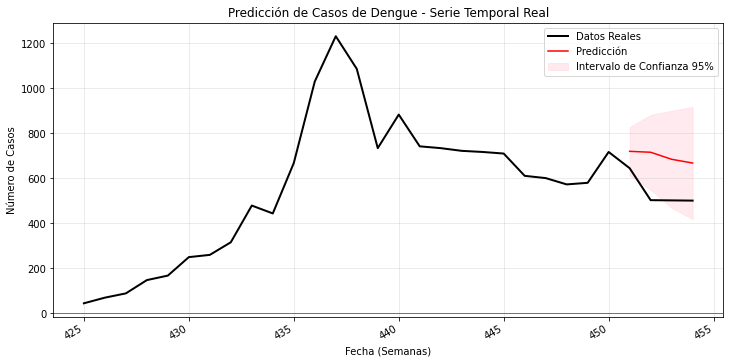

Error Absoluto Medio (MAE): 159.24 casos
Raíz del Error Cuadrático Medio (RMSE): 167.35 casos
Error Porcentual Absoluto Medio (MAPE): 30.89%


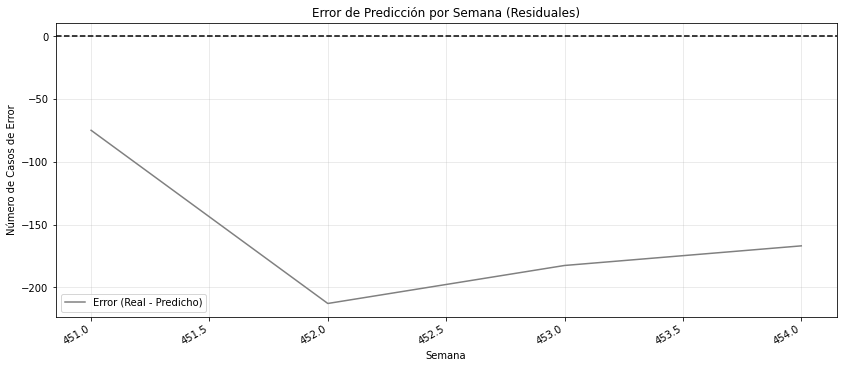

In [43]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX
n_forecast = 4
y = df["Casos_Dengue"]

train_y = y[:-n_forecast]
 
test_y = y[-n_forecast:]
 
model_final = SARIMAX(train_y, 
                       
                      order=(4, 1, 0), 
                      seasonal_order=(1, 1, 1, 52),
                      enforce_stationarity=False,
                      enforce_invertibility=False)
results_final = model_final.fit(disp=False)

forecast = results_final.get_forecast(steps=n_forecast )
forecast_df = forecast.summary_frame()
forecast_df.index = test_y.index

forecast_df['mean'] = np.clip(forecast_df['mean'], 0, None)
# forecast_df['mean_ci_lower'] = np.clip(forecast_df['mean_ci_lower'], 0, None)
# forecast_df['mean_ci_upper'] = np.clip(forecast_df['mean_ci_upper'], 0, None)

plt.figure(figsize=(12, 6))

plt.plot(y.index[-30:], y[-30:], label='Datos Reales', color='black', linewidth=2)

plt.plot(test_y.index, forecast_df['mean'], label='Predicción', color='red')

plt.fill_between(forecast_df.index, 
                 forecast_df['mean_ci_lower'], 
                 forecast_df['mean_ci_upper'], 
                 color='pink', alpha=0.3, label='Intervalo de Confianza 95%')

plt.gcf().autofmt_xdate() 

plt.title('Predicción de Casos de Dengue - Serie Temporal Real')
plt.xlabel('Fecha (Semanas)')
plt.ylabel('Número de Casos')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axhline(0, color='black', linewidth=1, alpha=0.5) # Línea en el cero
plt.show()
y_true = test_y
y_pred = forecast_df['mean']

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_true, y_pred)

print(f"Error Absoluto Medio (MAE): {mae:.2f} casos")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse:.2f} casos")
print(f"Error Porcentual Absoluto Medio (MAPE): {mape*100:.2f}%")

error_semanal = y_true - y_pred

plt.figure(figsize=(14, 6))
plt.plot(error_semanal.index, error_semanal, color='gray', label='Error (Real - Predicho)')
plt.axhline(0, color='black', linestyle='--', linewidth=1.5)
plt.title('Error de Predicción por Semana (Residuales)')
plt.xlabel('Semana')
plt.ylabel('Número de Casos de Error')
plt.legend()
plt.grid(True, alpha=0.3)
plt.gcf().autofmt_xdate()
plt.show()

In [1]:
print(111)

111


# Las Tunas

Index(['Año_x', 'Semana Estadística', 'Fecha', 'Casos_Dengue', 'Temp_Med',
       'Hum_Rel', 'Precip', 'Año_y', 'Mes'],
      dtype='object')


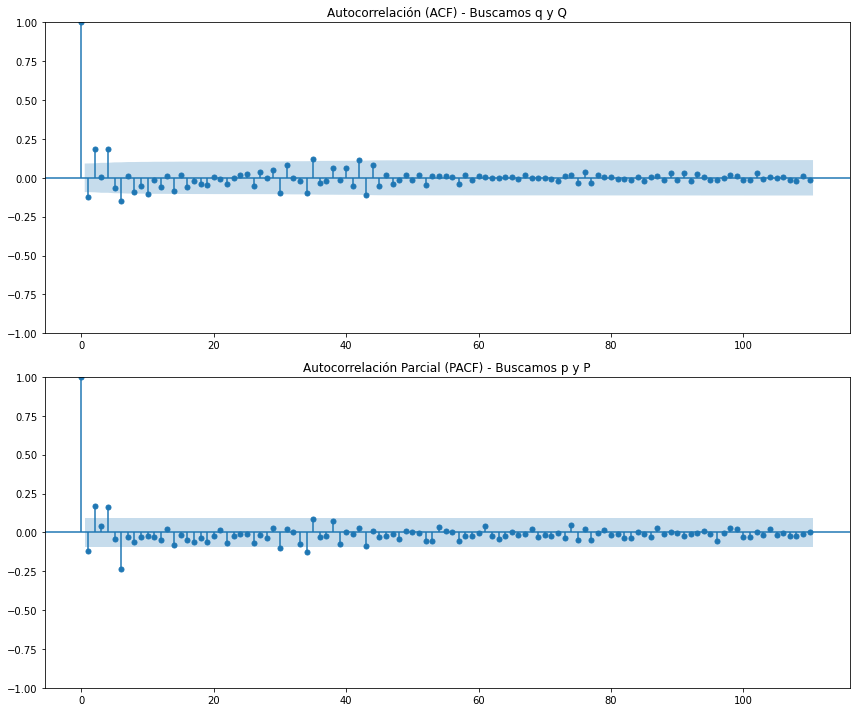

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import pandas as pd
import os

nombre_provincia = 'Las_Tunas'

carpeta_salida = 'dataframes_provincias'
nombre_archivo = f'{nombre_provincia.replace(" ", "_")}.csv'
ruta_completa = os.path.join(carpeta_salida, nombre_archivo)

df= pd.read_csv(ruta_completa)

df= df.drop(['Unnamed: 0', "Provincias"], axis=1)
print(df.columns)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

serie_diferenciada = df["Casos_Dengue"].diff().dropna()

# ACF: Ayuda a identificar q (MA) y Q (SMA)
plot_acf(serie_diferenciada, lags=110, ax=ax1)
ax1.set_title('Autocorrelación (ACF) - Buscamos q y Q')

# PACF: Ayuda a identificar p (AR) y P (SAR)
plot_pacf(serie_diferenciada, lags=110, ax=ax2)
ax2.set_title('Autocorrelación Parcial (PACF) - Buscamos p y P')

plt.tight_layout()
plt.show()

In [45]:
import itertools
import statsmodels.api as sm

p =  [0,1,2]
q=[0,1,2]
d = [1]
P = D = Q = range(0, 2) # Estacionales 0 o 1
s = 52 

pdq = list(itertools.product(p, d, q))
seasonal_pdq = [(x[0], x[1], x[2], s) for x in list(itertools.product(P, D, Q))]
y = df["Casos_Dengue"]

n_forecast = 4

train_y = y[:-n_forecast]
 
test_y = y[-n_forecast:]
 

mejores_params = None
mejor_aic = float("inf")

for param in pdq:
    for param_seasonal in seasonal_pdq:
        try:
            mod = sm.tsa.statespace.SARIMAX(train_y,
                                            
                                            order=param,
                                            seasonal_order=param_seasonal,
                                            enforce_stationarity=False,
                                            enforce_invertibility=False)
            results = mod.fit(disp=False)
            print(param,param_seasonal,results.aic)

            if results.aic < mejor_aic:
                mejor_aic = results.aic
                mejores_params = (param, param_seasonal)
                
        except:
            continue

print(f"Mejor SARIMA: {mejores_params} con AIC: {mejor_aic}")

(0, 1, 0) (0, 0, 0, 52) 4613.58843931689
(0, 1, 0) (0, 1, 0, 52) 4228.4231842067275
(0, 1, 0) (0, 1, 1, 52) 3646.7306925338553
(0, 1, 0) (1, 0, 0, 52) 4135.258736160987
(0, 1, 0) (1, 0, 1, 52) 4127.870851391545
(0, 1, 0) (1, 1, 0, 52) 3668.443727370987
(0, 1, 0) (1, 1, 1, 52) 3644.721481529287
(0, 1, 1) (0, 0, 0, 52) 4601.371789563929
(0, 1, 1) (0, 0, 1, 52) 4116.122865607505
(0, 1, 1) (0, 1, 0, 52) 4219.041771184962
(0, 1, 1) (0, 1, 1, 52) 3632.6564264624594
(0, 1, 1) (1, 0, 0, 52) 4133.576678901909
(0, 1, 1) (1, 0, 1, 52) 4116.818764101777
(0, 1, 1) (1, 1, 0, 52) 3667.466783511695
(0, 1, 1) (1, 1, 1, 52) 3632.267318070829
(0, 1, 2) (0, 0, 0, 52) 4580.745548763739
(0, 1, 2) (0, 0, 1, 52) 4096.390099526152
(0, 1, 2) (0, 1, 0, 52) 4200.603221937272
(0, 1, 2) (0, 1, 1, 52) 3617.4204315067764
(0, 1, 2) (1, 0, 0, 52) 4123.2211384446655
(0, 1, 2) (1, 0, 1, 52) 4097.086432279323
(0, 1, 2) (1, 1, 0, 52) 3660.7056258887455
(0, 1, 2) (1, 1, 1, 52) 3618.5979966862838
(1, 1, 0) (0, 0, 0, 52) 4608

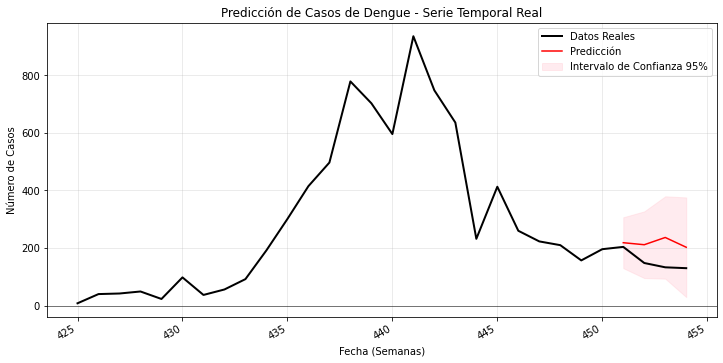

Error Absoluto Medio (MAE): 63.60 casos
Raíz del Error Cuadrático Medio (RMSE): 71.21 casos
Error Porcentual Absoluto Medio (MAPE): 45.98%


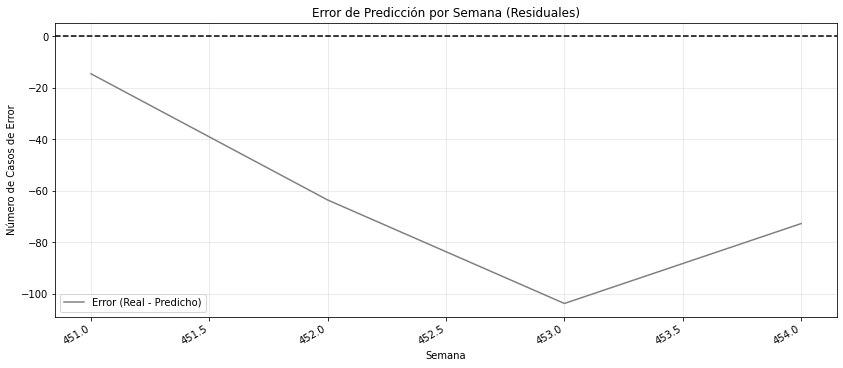

In [46]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX

model_final = SARIMAX(train_y, 
                       
                      order=(2, 1, 2), 
                      seasonal_order=(0, 1, 1, 52),
                      enforce_stationarity=False,
                      enforce_invertibility=False)
results_final = model_final.fit(disp=False)

forecast = results_final.get_forecast(steps=n_forecast )
forecast_df = forecast.summary_frame()
forecast_df.index = test_y.index

forecast_df['mean'] = np.clip(forecast_df['mean'], 0, None)
# forecast_df['mean_ci_lower'] = np.clip(forecast_df['mean_ci_lower'], 0, None)
# forecast_df['mean_ci_upper'] = np.clip(forecast_df['mean_ci_upper'], 0, None)

plt.figure(figsize=(12, 6))

plt.plot(y.index[-30:], y[-30:], label='Datos Reales', color='black', linewidth=2)

plt.plot(test_y.index, forecast_df['mean'], label='Predicción', color='red')

plt.fill_between(forecast_df.index, 
                 forecast_df['mean_ci_lower'], 
                 forecast_df['mean_ci_upper'], 
                 color='pink', alpha=0.3, label='Intervalo de Confianza 95%')

plt.gcf().autofmt_xdate() 

plt.title('Predicción de Casos de Dengue - Serie Temporal Real')
plt.xlabel('Fecha (Semanas)')
plt.ylabel('Número de Casos')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axhline(0, color='black', linewidth=1, alpha=0.5) # Línea en el cero
plt.show()
y_true = test_y
y_pred = forecast_df['mean']

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_true, y_pred)

print(f"Error Absoluto Medio (MAE): {mae:.2f} casos")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse:.2f} casos")
print(f"Error Porcentual Absoluto Medio (MAPE): {mape*100:.2f}%")

error_semanal = y_true - y_pred

plt.figure(figsize=(14, 6))
plt.plot(error_semanal.index, error_semanal, color='gray', label='Error (Real - Predicho)')
plt.axhline(0, color='black', linestyle='--', linewidth=1.5)
plt.title('Error de Predicción por Semana (Residuales)')
plt.xlabel('Semana')
plt.ylabel('Número de Casos de Error')
plt.legend()
plt.grid(True, alpha=0.3)
plt.gcf().autofmt_xdate()
plt.show()

# Granma

Index(['Año_x', 'Semana Estadística', 'Fecha', 'Casos_Dengue', 'Temp_Med',
       'Hum_Rel', 'Precip', 'Año_y', 'Mes'],
      dtype='object')


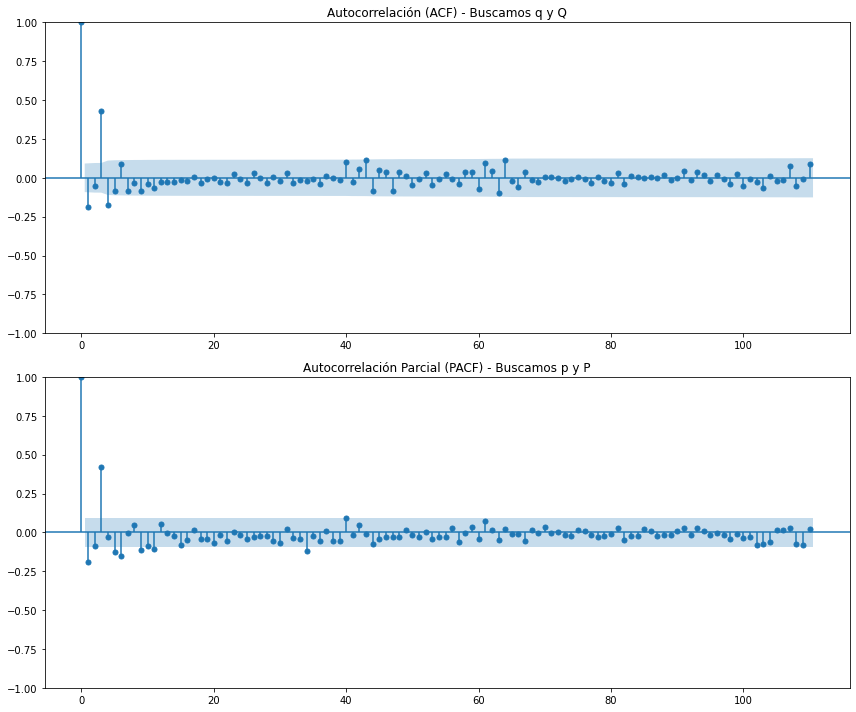

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import pandas as pd
import os

nombre_provincia = 'Granma'

carpeta_salida = 'dataframes_provincias'
nombre_archivo = f'{nombre_provincia.replace(" ", "_")}.csv'
ruta_completa = os.path.join(carpeta_salida, nombre_archivo)

df= pd.read_csv(ruta_completa)

df= df.drop(['Unnamed: 0', "Provincias"], axis=1)
print(df.columns)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

serie_diferenciada = df["Casos_Dengue"].diff().dropna()

# ACF: Ayuda a identificar q (MA) y Q (SMA)
plot_acf(serie_diferenciada, lags=110, ax=ax1)
ax1.set_title('Autocorrelación (ACF) - Buscamos q y Q')

# PACF: Ayuda a identificar p (AR) y P (SAR)
plot_pacf(serie_diferenciada, lags=110, ax=ax2)
ax2.set_title('Autocorrelación Parcial (PACF) - Buscamos p y P')

plt.tight_layout()
plt.show()

In [48]:
import itertools
import statsmodels.api as sm

p =  [0,1,2,3]
q=[0,1,2,3,4]
d = [1]
P = D = Q = range(0, 2) # Estacionales 0 o 1
s = 52 

pdq = list(itertools.product(p, d, q))
seasonal_pdq = [(x[0], x[1], x[2], s) for x in list(itertools.product(P, D, Q))]
y = df["Casos_Dengue"]

n_forecast = 4

train_y = y[:-n_forecast]
 
test_y = y[-n_forecast:]
 

mejores_params = None
mejor_aic = float("inf")

for param in pdq:
    for param_seasonal in seasonal_pdq:
        try:
            mod = sm.tsa.statespace.SARIMAX(train_y,
                                            
                                            order=param,
                                            seasonal_order=param_seasonal,
                                            enforce_stationarity=False,
                                            enforce_invertibility=False)
            results = mod.fit(disp=False)
            print(param,param_seasonal,results.aic)

            if results.aic < mejor_aic:
                mejor_aic = results.aic
                mejores_params = (param, param_seasonal)
                
        except:
            continue

print(f"Mejor SARIMA: {mejores_params} con AIC: {mejor_aic}")

(0, 1, 0) (0, 0, 0, 52) 3912.1788270572224
(0, 1, 0) (0, 0, 1, 52) 3509.7814124889587
(0, 1, 0) (0, 1, 0, 52) 3732.6528576420556
(0, 1, 0) (0, 1, 1, 52) 3126.284605645039
(0, 1, 0) (1, 0, 0, 52) 3517.538764566042
(0, 1, 0) (1, 0, 1, 52) 3511.708840094525
(0, 1, 0) (1, 1, 0, 52) 3212.115146811214
(0, 1, 0) (1, 1, 1, 52) 3128.261097854925
(0, 1, 1) (0, 0, 0, 52) 3890.158468257916
(0, 1, 1) (0, 0, 1, 52) 3489.7189261065855
(0, 1, 1) (0, 1, 0, 52) 3712.4941129650033
(0, 1, 1) (0, 1, 1, 52) 3109.0152517744536
(0, 1, 1) (1, 0, 0, 52) 3505.2928460327776
(0, 1, 1) (1, 0, 1, 52) 3491.6881922002144
(0, 1, 1) (1, 1, 0, 52) 3205.343101907175
(0, 1, 1) (1, 1, 1, 52) 3110.9902666613816
(0, 1, 2) (0, 0, 0, 52) 3861.990961685245
(0, 1, 2) (0, 0, 1, 52) 3464.100574029112
(0, 1, 2) (0, 1, 0, 52) 3683.39427551957
(0, 1, 2) (0, 1, 1, 52) 3088.9201916063043
(0, 1, 2) (1, 0, 0, 52) 3487.424308273032
(0, 1, 2) (1, 0, 1, 52) 3466.085276304989
(0, 1, 2) (1, 1, 0, 52) 3194.651891347473
(0, 1, 2) (1, 1, 1, 52) 3

/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(3, 1, 4) (1, 1, 1, 52) 3004.776161014468
Mejor SARIMA: ((3, 1, 4), (0, 1, 1, 52)) con AIC: 3002.7251574293878


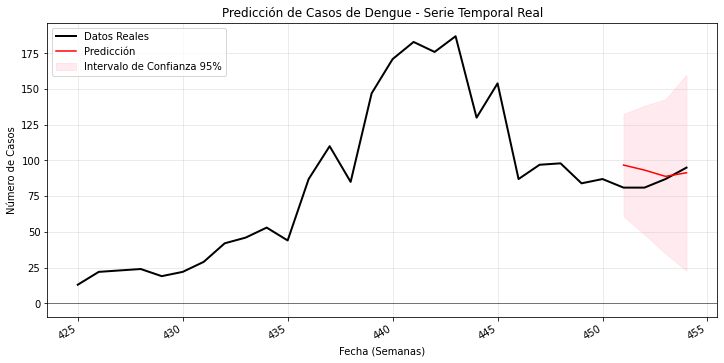

Error Absoluto Medio (MAE): 8.38 casos
Raíz del Error Cuadrático Medio (RMSE): 10.20 casos
Error Porcentual Absoluto Medio (MAPE): 10.14%


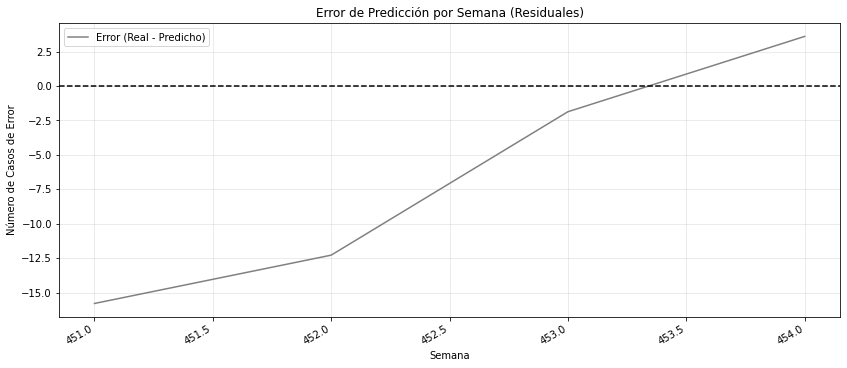

In [49]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX

model_final = SARIMAX(train_y, 
                       
                      order=(3, 1, 4), 
                      seasonal_order=(0, 1, 1, 52),
                      enforce_stationarity=False,
                      enforce_invertibility=False)
results_final = model_final.fit(disp=False)

forecast = results_final.get_forecast(steps=n_forecast )
forecast_df = forecast.summary_frame()
forecast_df.index = test_y.index

forecast_df['mean'] = np.clip(forecast_df['mean'], 0, None)
# forecast_df['mean_ci_lower'] = np.clip(forecast_df['mean_ci_lower'], 0, None)
# forecast_df['mean_ci_upper'] = np.clip(forecast_df['mean_ci_upper'], 0, None)

plt.figure(figsize=(12, 6))

plt.plot(y.index[-30:], y[-30:], label='Datos Reales', color='black', linewidth=2)

plt.plot(test_y.index, forecast_df['mean'], label='Predicción', color='red')

plt.fill_between(forecast_df.index, 
                 forecast_df['mean_ci_lower'], 
                 forecast_df['mean_ci_upper'], 
                 color='pink', alpha=0.3, label='Intervalo de Confianza 95%')

plt.gcf().autofmt_xdate() 

plt.title('Predicción de Casos de Dengue - Serie Temporal Real')
plt.xlabel('Fecha (Semanas)')
plt.ylabel('Número de Casos')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axhline(0, color='black', linewidth=1, alpha=0.5) # Línea en el cero
plt.show()
y_true = test_y
y_pred = forecast_df['mean']

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_true, y_pred)

print(f"Error Absoluto Medio (MAE): {mae:.2f} casos")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse:.2f} casos")
print(f"Error Porcentual Absoluto Medio (MAPE): {mape*100:.2f}%")

error_semanal = y_true - y_pred

plt.figure(figsize=(14, 6))
plt.plot(error_semanal.index, error_semanal, color='gray', label='Error (Real - Predicho)')
plt.axhline(0, color='black', linestyle='--', linewidth=1.5)
plt.title('Error de Predicción por Semana (Residuales)')
plt.xlabel('Semana')
plt.ylabel('Número de Casos de Error')
plt.legend()
plt.grid(True, alpha=0.3)
plt.gcf().autofmt_xdate()
plt.show()

# Holguin 

Index(['Año_x', 'Semana Estadística', 'Fecha', 'Casos_Dengue', 'Temp_Med',
       'Hum_Rel', 'Precip', 'Año_y', 'Mes'],
      dtype='object')


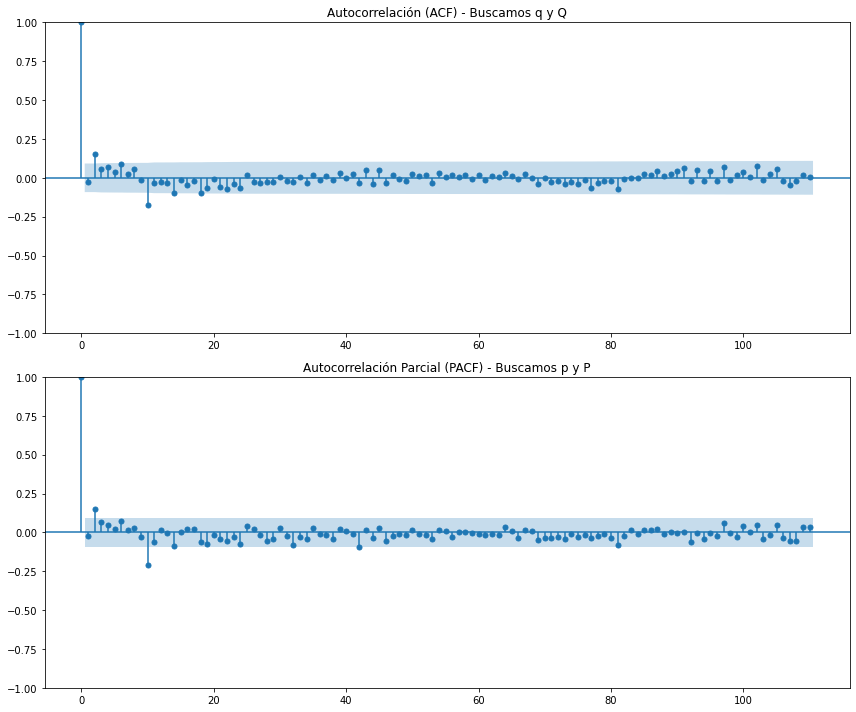

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import pandas as pd
import os

nombre_provincia = 'Holguín'

carpeta_salida = 'dataframes_provincias'
nombre_archivo = f'{nombre_provincia.replace(" ", "_")}.csv'
ruta_completa = os.path.join(carpeta_salida, nombre_archivo)

df= pd.read_csv(ruta_completa)

df= df.drop(['Unnamed: 0', "Provincias"], axis=1)
print(df.columns)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

serie_diferenciada = df["Casos_Dengue"].diff().dropna()

# ACF: Ayuda a identificar q (MA) y Q (SMA)
plot_acf(serie_diferenciada, lags=110, ax=ax1)
ax1.set_title('Autocorrelación (ACF) - Buscamos q y Q')

# PACF: Ayuda a identificar p (AR) y P (SAR)
plot_pacf(serie_diferenciada, lags=110, ax=ax2)
ax2.set_title('Autocorrelación Parcial (PACF) - Buscamos p y P')

plt.tight_layout()
plt.show()

In [2]:
import itertools
import statsmodels.api as sm

p =  [0,1,2]
q=[0,1,2]
d = [1]
P = D = Q = range(0, 2) # Estacionales 0 o 1
s = 52 

pdq = list(itertools.product(p, d, q))
seasonal_pdq = [(x[0], x[1], x[2], s) for x in list(itertools.product(P, D, Q))]
y = df["Casos_Dengue"]

n_forecast = 4

train_y = y[:-n_forecast]
 
test_y = y[-n_forecast:]
 

mejores_params = None
mejor_aic = float("inf")

for param in pdq:
    for param_seasonal in seasonal_pdq:
        try:
            mod = sm.tsa.statespace.SARIMAX(train_y,
                                            
                                            order=param,
                                            seasonal_order=param_seasonal,
                                            enforce_stationarity=False,
                                            enforce_invertibility=False)
            results = mod.fit(disp=False)
            print(param,param_seasonal,results.aic)

            if results.aic < mejor_aic:
                mejor_aic = results.aic
                mejores_params = (param, param_seasonal)
                
        except:
            continue

print(f"Mejor SARIMA: {mejores_params} con AIC: {mejor_aic}")

(0, 1, 0) (0, 0, 0, 52) 5078.547431199357
(0, 1, 0) (0, 0, 1, 52) 4505.404104420778
(0, 1, 0) (0, 1, 0, 52) 4724.7486716733665
(0, 1, 0) (0, 1, 1, 52) 3971.2934714028233
(0, 1, 0) (1, 0, 0, 52) 4515.705639335842
(0, 1, 0) (1, 0, 1, 52) 4507.362357853527
(0, 1, 0) (1, 1, 0, 52) 4034.8860215128907
(0, 1, 0) (1, 1, 1, 52) 3972.96963284943
(0, 1, 1) (0, 0, 0, 52) 5070.016131423995
(0, 1, 1) (0, 0, 1, 52) 4496.967989244613
(0, 1, 1) (0, 1, 0, 52) 4715.83615606265
(0, 1, 1) (0, 1, 1, 52) 3962.8225313367
(0, 1, 1) (1, 0, 0, 52) 4517.608075465818
(0, 1, 1) (1, 0, 1, 52) 4498.92555953139
(0, 1, 1) (1, 1, 0, 52) 4036.207171328667
(0, 1, 1) (1, 1, 1, 52) 3964.483687201693
(0, 1, 2) (0, 0, 0, 52) 5051.442250802942
(0, 1, 2) (0, 0, 1, 52) 4478.158584478942
(0, 1, 2) (0, 1, 0, 52) 4704.385142564072
(0, 1, 2) (0, 1, 1, 52) 3946.239340068788
(0, 1, 2) (1, 0, 0, 52) 4509.111300480242
(0, 1, 2) (1, 0, 1, 52) 4480.1569003434715
(0, 1, 2) (1, 1, 0, 52) 4032.5693379603945
(0, 1, 2) (1, 1, 1, 52) 3947.97095

/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(2, 1, 2) (1, 1, 1, 52) 3953.9093094640866
Mejor SARIMA: ((1, 1, 2), (0, 1, 1, 52)) con AIC: 3945.8415618806553


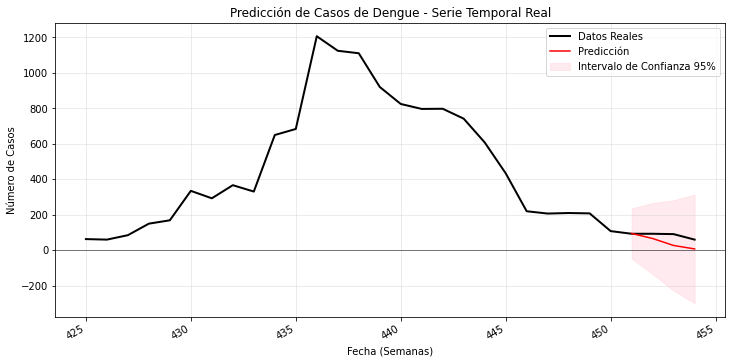

Error Absoluto Medio (MAE): 36.24 casos
Raíz del Error Cuadrático Medio (RMSE): 43.51 casos
Error Porcentual Absoluto Medio (MAPE): 47.75%


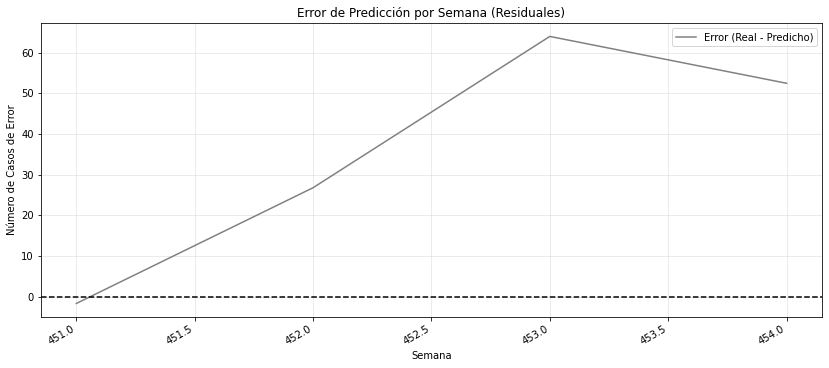

In [3]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX
y = df["Casos_Dengue"]

n_forecast = 4

train_y = y[:-n_forecast]
 
test_y = y[-n_forecast:]
model_final = SARIMAX(train_y, 
                       
                      order=(1, 1, 2), 
                      seasonal_order=(0, 1, 1, 52),
                      enforce_stationarity=False,
                      enforce_invertibility=False)
results_final = model_final.fit(disp=False)

forecast = results_final.get_forecast(steps=n_forecast )
forecast_df = forecast.summary_frame()
forecast_df.index = test_y.index

forecast_df['mean'] = np.clip(forecast_df['mean'], 0, None)
# forecast_df['mean_ci_lower'] = np.clip(forecast_df['mean_ci_lower'], 0, None)
# forecast_df['mean_ci_upper'] = np.clip(forecast_df['mean_ci_upper'], 0, None)

plt.figure(figsize=(12, 6))

plt.plot(y.index[-30:], y[-30:], label='Datos Reales', color='black', linewidth=2)

plt.plot(test_y.index, forecast_df['mean'], label='Predicción', color='red')

plt.fill_between(forecast_df.index, 
                 forecast_df['mean_ci_lower'], 
                 forecast_df['mean_ci_upper'], 
                 color='pink', alpha=0.3, label='Intervalo de Confianza 95%')

plt.gcf().autofmt_xdate() 

plt.title('Predicción de Casos de Dengue - Serie Temporal Real')
plt.xlabel('Fecha (Semanas)')
plt.ylabel('Número de Casos')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axhline(0, color='black', linewidth=1, alpha=0.5) # Línea en el cero
plt.show()
y_true = test_y
y_pred = forecast_df['mean']

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_true, y_pred)

print(f"Error Absoluto Medio (MAE): {mae:.2f} casos")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse:.2f} casos")
print(f"Error Porcentual Absoluto Medio (MAPE): {mape*100:.2f}%")

error_semanal = y_true - y_pred

plt.figure(figsize=(14, 6))
plt.plot(error_semanal.index, error_semanal, color='gray', label='Error (Real - Predicho)')
plt.axhline(0, color='black', linestyle='--', linewidth=1.5)
plt.title('Error de Predicción por Semana (Residuales)')
plt.xlabel('Semana')
plt.ylabel('Número de Casos de Error')
plt.legend()
plt.grid(True, alpha=0.3)
plt.gcf().autofmt_xdate()
plt.show()

# Santiago de Cuba 

Index(['Año_x', 'Semana Estadística', 'Fecha', 'Casos_Dengue', 'Temp_Med',
       'Hum_Rel', 'Precip', 'Año_y', 'Mes'],
      dtype='object')


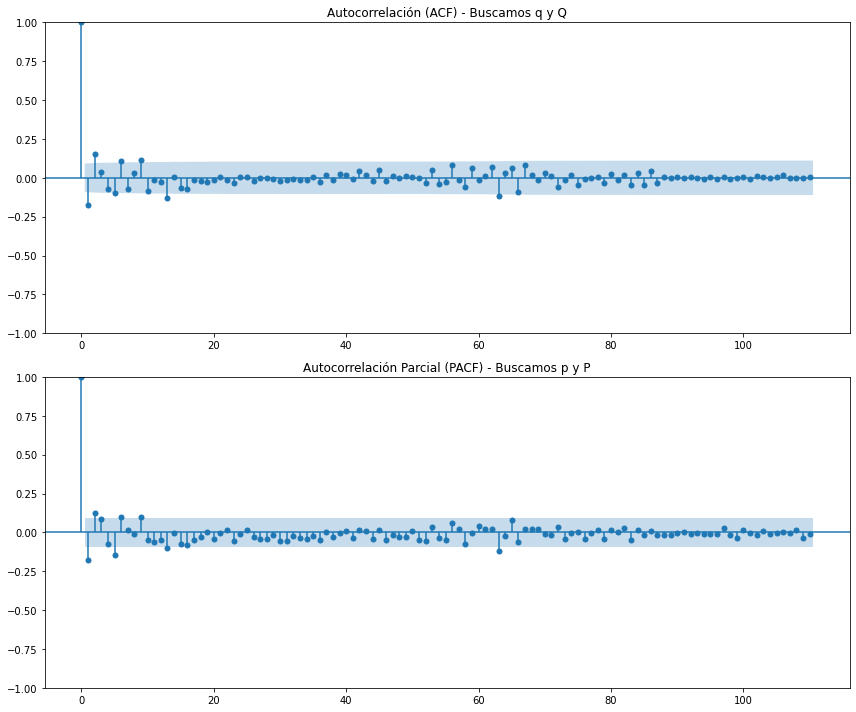

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import pandas as pd
import os

nombre_provincia = 'Santiago_de_Cuba'

carpeta_salida = 'dataframes_provincias'
nombre_archivo = f'{nombre_provincia.replace(" ", "_")}.csv'
ruta_completa = os.path.join(carpeta_salida, nombre_archivo)

df= pd.read_csv(ruta_completa)

df= df.drop(['Unnamed: 0', "Provincias"], axis=1)
print(df.columns)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

serie_diferenciada = df["Casos_Dengue"].diff().dropna()

# ACF: Ayuda a identificar q (MA) y Q (SMA)
plot_acf(serie_diferenciada, lags=110, ax=ax1)
ax1.set_title('Autocorrelación (ACF) - Buscamos q y Q')

# PACF: Ayuda a identificar p (AR) y P (SAR)
plot_pacf(serie_diferenciada, lags=110, ax=ax2)
ax2.set_title('Autocorrelación Parcial (PACF) - Buscamos p y P')

plt.tight_layout()
plt.show()

In [5]:
import itertools
import statsmodels.api as sm

p =  [0,1,2,3]
q=[0,1,2]
d = [1]
P = D = Q = range(0, 2) # Estacionales 0 o 1
s = 52 

pdq = list(itertools.product(p, d, q))
seasonal_pdq = [(x[0], x[1], x[2], s) for x in list(itertools.product(P, D, Q))]
y = df["Casos_Dengue"]

n_forecast = 4

train_y = y[:-n_forecast]
 
test_y = y[-n_forecast:]
 

mejores_params = None
mejor_aic = float("inf")

for param in pdq:
    for param_seasonal in seasonal_pdq:
        try:
            mod = sm.tsa.statespace.SARIMAX(train_y,
                                            
                                            order=param,
                                            seasonal_order=param_seasonal,
                                            enforce_stationarity=False,
                                            enforce_invertibility=False)
            results = mod.fit(disp=False)
            print(param,param_seasonal,results.aic)

            if results.aic < mejor_aic:
                mejor_aic = results.aic
                mejores_params = (param, param_seasonal)
                
        except:
            continue

print(f"Mejor SARIMA: {mejores_params} con AIC: {mejor_aic}")

(0, 1, 0) (0, 0, 0, 52) 5667.477104691403
(0, 1, 0) (0, 0, 1, 52) 4985.292123735003
(0, 1, 0) (0, 1, 0, 52) 5246.764667059264
(0, 1, 0) (0, 1, 1, 52) 4308.428439451055
(0, 1, 0) (1, 0, 0, 52) 4996.207868811131
(0, 1, 0) (1, 0, 1, 52) 4967.517367034407
(0, 1, 0) (1, 1, 0, 52) 4347.503611601205
(0, 1, 0) (1, 1, 1, 52) 4336.957134979803
(0, 1, 1) (0, 0, 0, 52) 5640.807302676294
(0, 1, 1) (0, 0, 1, 52) 4966.014356526917
(0, 1, 1) (0, 1, 0, 52) 5207.3157442526335
(0, 1, 1) (0, 1, 1, 52) 4298.257031174328
(0, 1, 1) (1, 0, 0, 52) 4988.654725710474
(0, 1, 1) (1, 0, 1, 52) 4955.454454382692
(0, 1, 1) (1, 1, 0, 52) 4349.3191930451485
(0, 1, 1) (1, 1, 1, 52) 4299.681593904379
(0, 1, 2) (0, 0, 0, 52) 5619.963108282702
(0, 1, 2) (0, 0, 1, 52) 4927.989633615368
(0, 1, 2) (0, 1, 0, 52) 5179.153474436687
(0, 1, 2) (0, 1, 1, 52) 4282.547120173178
(0, 1, 2) (1, 0, 0, 52) 4963.052703863779
(0, 1, 2) (1, 0, 1, 52) 4919.206393895993
(0, 1, 2) (1, 1, 0, 52) 4341.881953646387
(0, 1, 2) (1, 1, 1, 52) 4283.843

/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(2, 1, 1) (1, 1, 1, 52) 4298.318910278056
(2, 1, 2) (0, 0, 0, 52) 5615.3972637030765
(2, 1, 2) (0, 0, 1, 52) 4912.052209836126
(2, 1, 2) (0, 1, 0, 52) 5167.747156456949


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(2, 1, 2) (0, 1, 1, 52) 4285.29210264316
(2, 1, 2) (1, 0, 0, 52) 4923.867807850432
(2, 1, 2) (1, 0, 1, 52) 4906.193977272722
(2, 1, 2) (1, 1, 0, 52) 4328.047098063432


...

(3, 1, 2) (0, 1, 1, 52) 4284.927666439853
(3, 1, 2) (1, 0, 0, 52) 4914.010277211081


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(3, 1, 2) (1, 0, 1, 52) 4907.8208048423
(3, 1, 2) (1, 1, 0, 52) 4303.885588352336


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(3, 1, 2) (1, 1, 1, 52) 4276.825490286978
Mejor SARIMA: ((3, 1, 2), (1, 1, 1, 52)) con AIC: 4276.825490286978


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


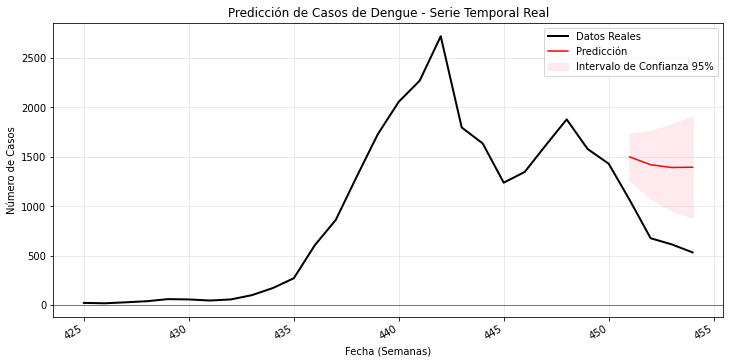

Error Absoluto Medio (MAE): 704.33 casos
Raíz del Error Cuadrático Medio (RMSE): 722.50 casos
Error Porcentual Absoluto Medio (MAPE): 109.60%


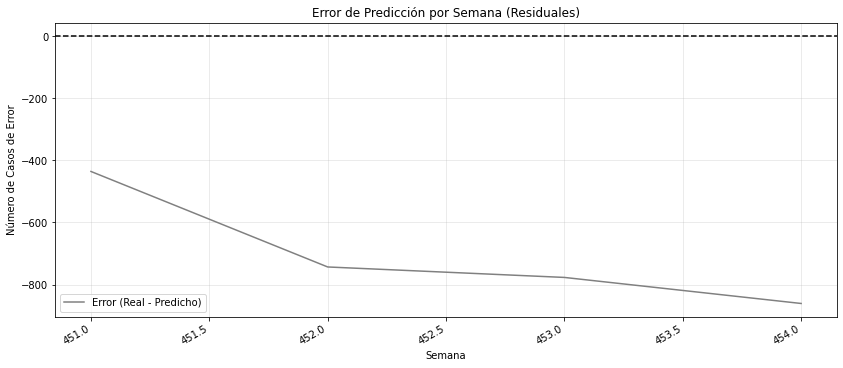

In [6]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX

model_final = SARIMAX(train_y, 
                       
                      order=(3, 1, 2), 
                      seasonal_order=(1, 1, 1, 52),
                      enforce_stationarity=False,
                      enforce_invertibility=False)
results_final = model_final.fit(disp=False)

forecast = results_final.get_forecast(steps=n_forecast )
forecast_df = forecast.summary_frame()
forecast_df.index = test_y.index

forecast_df['mean'] = np.clip(forecast_df['mean'], 0, None)
# forecast_df['mean_ci_lower'] = np.clip(forecast_df['mean_ci_lower'], 0, None)
# forecast_df['mean_ci_upper'] = np.clip(forecast_df['mean_ci_upper'], 0, None)

plt.figure(figsize=(12, 6))

plt.plot(y.index[-30:], y[-30:], label='Datos Reales', color='black', linewidth=2)

plt.plot(test_y.index, forecast_df['mean'], label='Predicción', color='red')

plt.fill_between(forecast_df.index, 
                 forecast_df['mean_ci_lower'], 
                 forecast_df['mean_ci_upper'], 
                 color='pink', alpha=0.3, label='Intervalo de Confianza 95%')

plt.gcf().autofmt_xdate() 

plt.title('Predicción de Casos de Dengue - Serie Temporal Real')
plt.xlabel('Fecha (Semanas)')
plt.ylabel('Número de Casos')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axhline(0, color='black', linewidth=1, alpha=0.5) # Línea en el cero
plt.show()
y_true = test_y
y_pred = forecast_df['mean']

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_true, y_pred)

print(f"Error Absoluto Medio (MAE): {mae:.2f} casos")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse:.2f} casos")
print(f"Error Porcentual Absoluto Medio (MAPE): {mape*100:.2f}%")

error_semanal = y_true - y_pred

plt.figure(figsize=(14, 6))
plt.plot(error_semanal.index, error_semanal, color='gray', label='Error (Real - Predicho)')
plt.axhline(0, color='black', linestyle='--', linewidth=1.5)
plt.title('Error de Predicción por Semana (Residuales)')
plt.xlabel('Semana')
plt.ylabel('Número de Casos de Error')
plt.legend()
plt.grid(True, alpha=0.3)
plt.gcf().autofmt_xdate()
plt.show()

# Guantanamo 

Index(['Año_x', 'Semana Estadística', 'Fecha', 'Casos_Dengue', 'Temp_Med',
       'Hum_Rel', 'Precip', 'Año_y', 'Mes'],
      dtype='object')


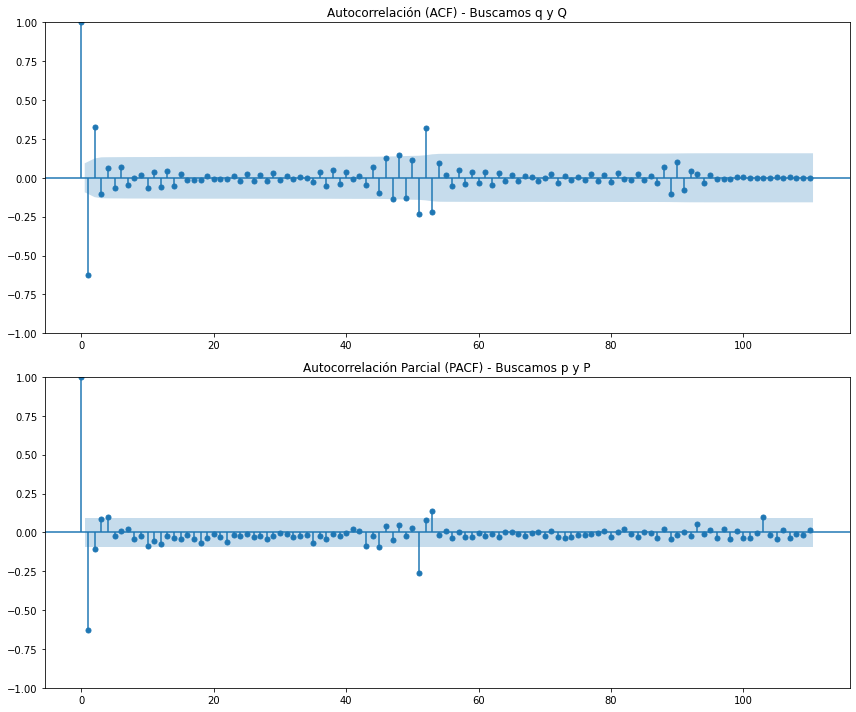

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import pandas as pd
import os

nombre_provincia = 'Guantánamo'

carpeta_salida = 'dataframes_provincias'
nombre_archivo = f'{nombre_provincia.replace(" ", "_")}.csv'
ruta_completa = os.path.join(carpeta_salida, nombre_archivo)

df= pd.read_csv(ruta_completa)

df= df.drop(['Unnamed: 0', "Provincias"], axis=1)
print(df.columns)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

serie_diferenciada = df["Casos_Dengue"].diff().dropna()

# ACF: Ayuda a identificar q (MA) y Q (SMA)
plot_acf(serie_diferenciada, lags=110, ax=ax1)
ax1.set_title('Autocorrelación (ACF) - Buscamos q y Q')

# PACF: Ayuda a identificar p (AR) y P (SAR)
plot_pacf(serie_diferenciada, lags=110, ax=ax2)
ax2.set_title('Autocorrelación Parcial (PACF) - Buscamos p y P')

plt.tight_layout()
plt.show()

In [8]:
import itertools
import statsmodels.api as sm

p =  [0,1,2]
q=[0,1,2]
d = [1]
P = D = Q = range(0, 2) # Estacionales 0 o 1
s = 52 

pdq = list(itertools.product(p, d, q))
seasonal_pdq = [(x[0], x[1], x[2], s) for x in list(itertools.product(P, D, Q))]
y = df["Casos_Dengue"]

n_forecast = 4

train_y = y[:-n_forecast]
 
test_y = y[-n_forecast:]
 

mejores_params = None
mejor_aic = float("inf")

for param in pdq:
    for param_seasonal in seasonal_pdq:
        try:
            mod = sm.tsa.statespace.SARIMAX(train_y,
                                            
                                            order=param,
                                            seasonal_order=param_seasonal,
                                            enforce_stationarity=False,
                                            enforce_invertibility=False)
            results = mod.fit(disp=False)
            print(param,param_seasonal,results.aic)

            if results.aic < mejor_aic:
                mejor_aic = results.aic
                mejores_params = (param, param_seasonal)
                
        except:
            continue

print(f"Mejor SARIMA: {mejores_params} con AIC: {mejor_aic}")

(0, 1, 0) (0, 0, 0, 52) 5387.543061672566
(0, 1, 0) (0, 0, 1, 52) 4662.722384593172
(0, 1, 0) (0, 1, 0, 52) 4787.036031184955
(0, 1, 0) (0, 1, 1, 52) 4046.800952030806
(0, 1, 0) (1, 0, 0, 52) 4606.767657916078
(0, 1, 0) (1, 0, 1, 52) 4446.127514798036
(0, 1, 0) (1, 1, 0, 52) 4061.0644528710636
(0, 1, 0) (1, 1, 1, 52) 3975.190087080303
(0, 1, 1) (0, 0, 0, 52) 5208.5885597816805
(0, 1, 1) (0, 0, 1, 52) 4524.349303316403
(0, 1, 1) (0, 1, 0, 52) 4648.322909489874
(0, 1, 1) (0, 1, 1, 52) 3937.135238056568
(0, 1, 1) (1, 0, 0, 52) 4494.829915343771
(0, 1, 1) (1, 0, 1, 52) 4362.699228572802
(0, 1, 1) (1, 1, 0, 52) 3962.66178522234
(0, 1, 1) (1, 1, 1, 52) 3898.142963404655
(0, 1, 2) (0, 0, 0, 52) 5141.874780903985
(0, 1, 2) (0, 0, 1, 52) 4440.345878096329
(0, 1, 2) (0, 1, 0, 52) 4581.489620443776
(0, 1, 2) (0, 1, 1, 52) 3874.897421767985
(0, 1, 2) (1, 0, 0, 52) 4411.307486127456
(0, 1, 2) (1, 0, 1, 52) 4268.3371348979
(0, 1, 2) (1, 1, 0, 52) 3911.52997602087
(0, 1, 2) (1, 1, 1, 52) 3846.3372543

/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(2, 1, 1) (0, 1, 0, 52) 4599.297107646923
(2, 1, 1) (0, 1, 1, 52) 3898.867347556355
(2, 1, 1) (1, 0, 0, 52) 4419.752300181397
(2, 1, 1) (1, 0, 1, 52) 4309.961985192356
(2, 1, 1) (1, 1, 0, 52) 3901.7474199185826
(2, 1, 1) (1, 1, 1, 52) 3866.1162950218177
(2, 1, 2) (0, 0, 0, 52) 5140.1704528937025
(2, 1, 2) (0, 0, 1, 52) 4434.16790683882
(2, 1, 2) (0, 1, 0, 52) 4571.628313793068
(2, 1, 2) (0, 1, 1, 52) 3877.0469339405063
(2, 1, 2) (1, 0, 0, 52) 4378.920182460249
(2, 1, 2) (1, 0, 1, 52) 4268.252856454248
(2, 1, 2) (1, 1, 0, 52) 3890.7691075680564
(2, 1, 2) (1, 1, 1, 52) 3848.439887232908
Mejor SARIMA: ((0, 1, 2), (1, 1, 1, 52)) con AIC: 3846.3372543618616


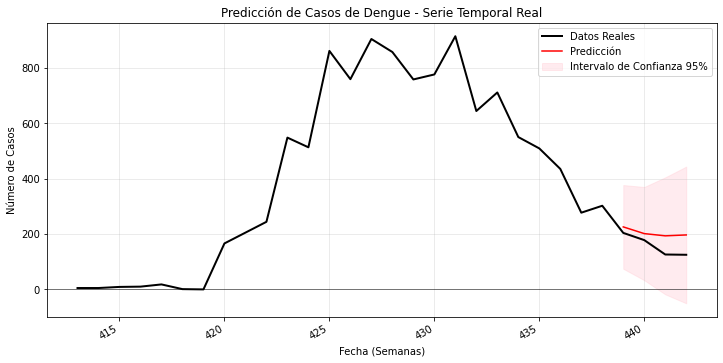

Error Absoluto Medio (MAE): 46.03 casos
Raíz del Error Cuadrático Medio (RMSE): 51.70 casos
Error Porcentual Absoluto Medio (MAPE): 33.65%


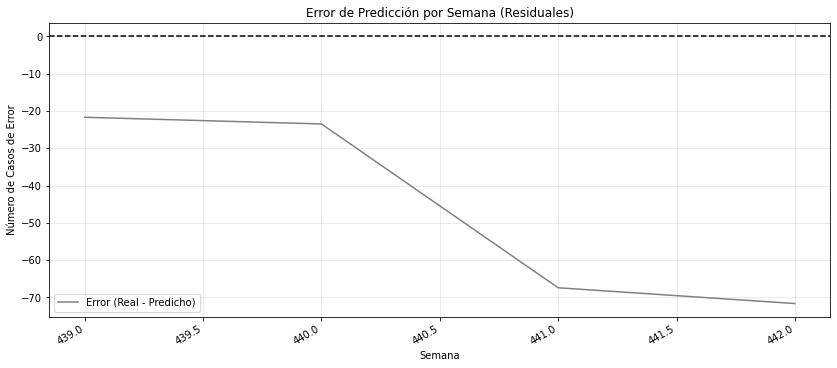

In [9]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX

model_final = SARIMAX(train_y, 
                       
                      order=(0, 1, 2), 
                      seasonal_order=(1, 1, 1, 52),
                      enforce_stationarity=False,
                      enforce_invertibility=False)
results_final = model_final.fit(disp=False)

forecast = results_final.get_forecast(steps=n_forecast )
forecast_df = forecast.summary_frame()
forecast_df.index = test_y.index

forecast_df['mean'] = np.clip(forecast_df['mean'], 0, None)
# forecast_df['mean_ci_lower'] = np.clip(forecast_df['mean_ci_lower'], 0, None)
# forecast_df['mean_ci_upper'] = np.clip(forecast_df['mean_ci_upper'], 0, None)

plt.figure(figsize=(12, 6))

plt.plot(y.index[-30:], y[-30:], label='Datos Reales', color='black', linewidth=2)

plt.plot(test_y.index, forecast_df['mean'], label='Predicción', color='red')

plt.fill_between(forecast_df.index, 
                 forecast_df['mean_ci_lower'], 
                 forecast_df['mean_ci_upper'], 
                 color='pink', alpha=0.3, label='Intervalo de Confianza 95%')

plt.gcf().autofmt_xdate() 

plt.title('Predicción de Casos de Dengue - Serie Temporal Real')
plt.xlabel('Fecha (Semanas)')
plt.ylabel('Número de Casos')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axhline(0, color='black', linewidth=1, alpha=0.5) # Línea en el cero
plt.show()
y_true = test_y
y_pred = forecast_df['mean']

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_true, y_pred)

print(f"Error Absoluto Medio (MAE): {mae:.2f} casos")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse:.2f} casos")
print(f"Error Porcentual Absoluto Medio (MAPE): {mape*100:.2f}%")

error_semanal = y_true - y_pred

plt.figure(figsize=(14, 6))
plt.plot(error_semanal.index, error_semanal, color='gray', label='Error (Real - Predicho)')
plt.axhline(0, color='black', linestyle='--', linewidth=1.5)
plt.title('Error de Predicción por Semana (Residuales)')
plt.xlabel('Semana')
plt.ylabel('Número de Casos de Error')
plt.legend()
plt.grid(True, alpha=0.3)
plt.gcf().autofmt_xdate()
plt.show()

# Isla de la Juventud 

Index(['Año_x', 'Semana Estadística', 'Fecha', 'Casos_Dengue', 'Temp_Med',
       'Hum_Rel', 'Precip', 'Año_y', 'Mes'],
      dtype='object')


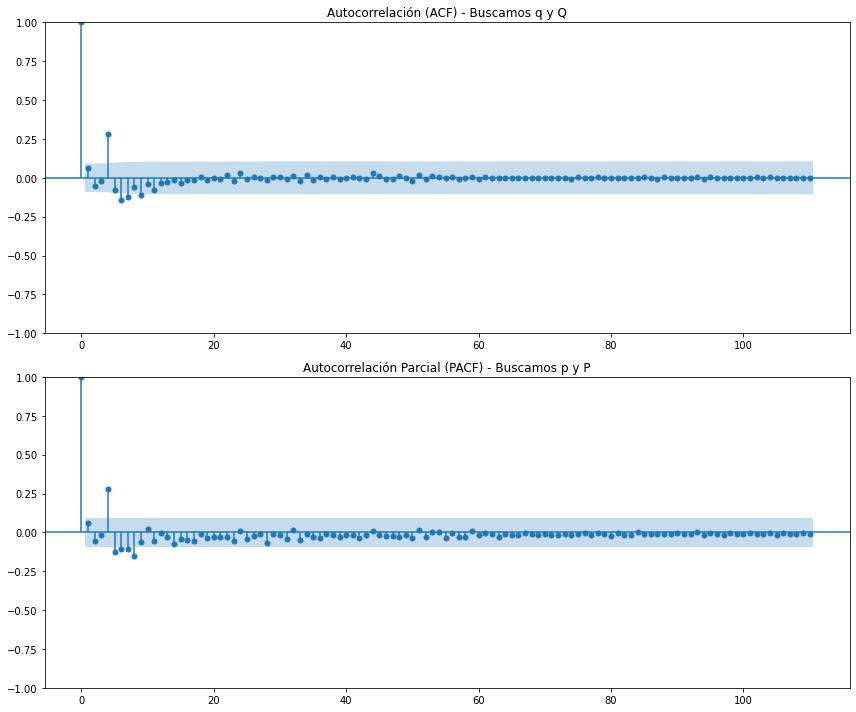

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import pandas as pd
import os

nombre_provincia = 'Isla_de_la_Juventud'

carpeta_salida = 'dataframes_provincias'
nombre_archivo = f'{nombre_provincia.replace(" ", "_")}.csv'
ruta_completa = os.path.join(carpeta_salida, nombre_archivo)

df= pd.read_csv(ruta_completa)

df= df.drop(['Unnamed: 0', "Provincias"], axis=1)
print(df.columns)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

serie_diferenciada = df["Casos_Dengue"].diff().dropna()

# ACF: Ayuda a identificar q (MA) y Q (SMA)
plot_acf(serie_diferenciada, lags=110, ax=ax1)
ax1.set_title('Autocorrelación (ACF) - Buscamos q y Q')

# PACF: Ayuda a identificar p (AR) y P (SAR)
plot_pacf(serie_diferenciada, lags=110, ax=ax2)
ax2.set_title('Autocorrelación Parcial (PACF) - Buscamos p y P')

plt.tight_layout()
plt.show()

In [11]:
import itertools
import statsmodels.api as sm

p =  [0,1,2]
q=[0,1,2]
d = [1]
P = D = Q = range(0, 2) # Estacionales 0 o 1
s = 52 

pdq = list(itertools.product(p, d, q))
seasonal_pdq = [(x[0], x[1], x[2], s) for x in list(itertools.product(P, D, Q))]
y = df["Casos_Dengue"]
n_forecast = 4

train_y = y[:-n_forecast]
 
test_y = y[-n_forecast:]
 

mejores_params = None
mejor_aic = float("inf")

for param in pdq:
    for param_seasonal in seasonal_pdq:
        try:
            mod = sm.tsa.statespace.SARIMAX(train_y,
                                            
                                            order=param,
                                            seasonal_order=param_seasonal,
                                            enforce_stationarity=False,
                                            enforce_invertibility=False)
            results = mod.fit(disp=False)
            print(param,param_seasonal,results.aic)

            if results.aic < mejor_aic:
                mejor_aic = results.aic
                mejores_params = (param, param_seasonal)
                
        except:
            continue

print(f"Mejor SARIMA: {mejores_params} con AIC: {mejor_aic}")

(0, 1, 0) (0, 0, 0, 52) 3560.3214564564696
(0, 1, 0) (0, 0, 1, 52) 3123.2470462928327
(0, 1, 0) (0, 1, 0, 52) 3217.147237847003
(0, 1, 0) (0, 1, 1, 52) 2769.2393370520695
(0, 1, 0) (1, 0, 0, 52) 3129.956282598157
(0, 1, 0) (1, 0, 1, 52) 3124.9653588510423
(0, 1, 0) (1, 1, 0, 52) 2776.272933244577
(0, 1, 0) (1, 1, 1, 52) 2770.6335165004834
(0, 1, 1) (0, 0, 0, 52) 3553.5734912163034
(0, 1, 1) (0, 0, 1, 52) 3087.732876141914
(0, 1, 1) (0, 1, 0, 52) 3211.6113263676048
(0, 1, 1) (0, 1, 1, 52) 2739.375596261568
(0, 1, 1) (1, 0, 0, 52) 3100.880783014889
(0, 1, 1) (1, 0, 1, 52) 3088.8995866619557
(0, 1, 1) (1, 1, 0, 52) 2753.73314069287
(0, 1, 1) (1, 1, 1, 52) 2740.2727451241126
(0, 1, 2) (0, 0, 0, 52) 3547.9876365793334
(0, 1, 2) (0, 0, 1, 52) 3081.3257762435373
(0, 1, 2) (0, 1, 0, 52) 3206.2372283611567
(0, 1, 2) (0, 1, 1, 52) 2733.0774994213916
(0, 1, 2) (1, 0, 0, 52) 3101.269073216802
(0, 1, 2) (1, 0, 1, 52) 3082.5431597213155
(0, 1, 2) (1, 1, 0, 52) 2754.3507788681773
(0, 1, 2) (1, 1, 1, 

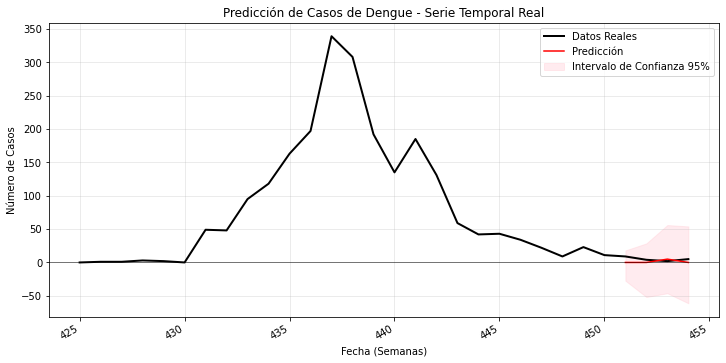

Error Absoluto Medio (MAE): 5.24 casos
Raíz del Error Cuadrático Medio (RMSE): 5.72 casos
Error Porcentual Absoluto Medio (MAPE): 112.15%


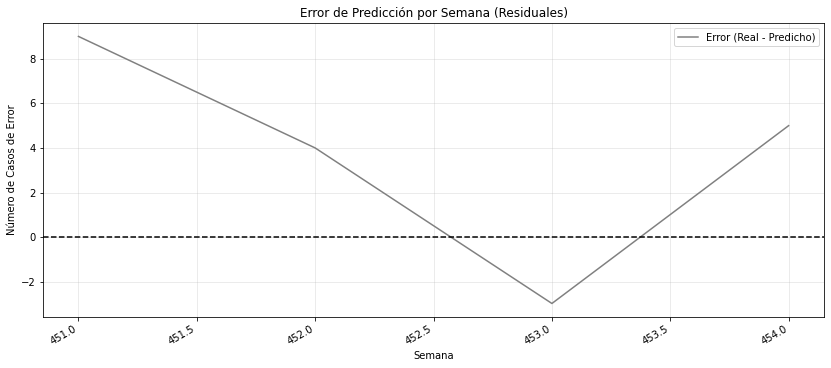

In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX

model_final = SARIMAX(train_y, 
                       
                      order=(2, 1, 2), 
                      seasonal_order=(1, 1, 1, 52),
                      enforce_stationarity=False,
                      enforce_invertibility=False)
results_final = model_final.fit(disp=False)

forecast = results_final.get_forecast(steps=n_forecast )
forecast_df = forecast.summary_frame()
forecast_df.index = test_y.index

forecast_df['mean'] = np.clip(forecast_df['mean'], 0, None)
# forecast_df['mean_ci_lower'] = np.clip(forecast_df['mean_ci_lower'], 0, None)
# forecast_df['mean_ci_upper'] = np.clip(forecast_df['mean_ci_upper'], 0, None)

plt.figure(figsize=(12, 6))

plt.plot(y.index[-30:], y[-30:], label='Datos Reales', color='black', linewidth=2)

plt.plot(test_y.index, forecast_df['mean'], label='Predicción', color='red')

plt.fill_between(forecast_df.index, 
                 forecast_df['mean_ci_lower'], 
                 forecast_df['mean_ci_upper'], 
                 color='pink', alpha=0.3, label='Intervalo de Confianza 95%')

plt.gcf().autofmt_xdate() 

plt.title('Predicción de Casos de Dengue - Serie Temporal Real')
plt.xlabel('Fecha (Semanas)')
plt.ylabel('Número de Casos')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axhline(0, color='black', linewidth=1, alpha=0.5) # Línea en el cero
plt.show()
y_true = test_y
y_pred = forecast_df['mean']

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_true, y_pred)

print(f"Error Absoluto Medio (MAE): {mae:.2f} casos")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse:.2f} casos")
print(f"Error Porcentual Absoluto Medio (MAPE): {mape*100:.2f}%")

error_semanal = y_true - y_pred

plt.figure(figsize=(14, 6))
plt.plot(error_semanal.index, error_semanal, color='gray', label='Error (Real - Predicho)')
plt.axhline(0, color='black', linestyle='--', linewidth=1.5)
plt.title('Error de Predicción por Semana (Residuales)')
plt.xlabel('Semana')
plt.ylabel('Número de Casos de Error')
plt.legend()
plt.grid(True, alpha=0.3)
plt.gcf().autofmt_xdate()
plt.show()